In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import torch
import numpy as np
import matplotlib.pyplot as plt
import entropy_utils as entu
from entropy_utils import uncertainties, entropy

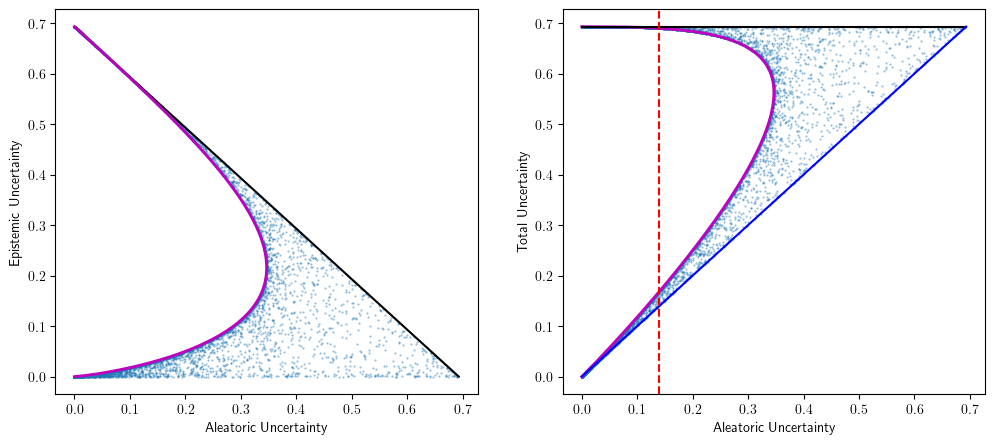

In [91]:
num_classes = 2
num_samples = 10000
num_ensemble = 2

logit_std = 20
corr1 = 0.5
corr2 = 0.5


logits = torch.randn(num_ensemble, num_samples, num_classes)*logit_std
if corr1>0:
    logits = (torch.randn(1, num_samples, num_classes)*logit_std*corr1 + 
              logits*(1-corr1))
if corr2>0:
    logits = (torch.randn(num_ensemble, num_samples, 1)*logit_std*corr2 + 
              logits*(1-corr2))
probs = torch.softmax(logits, dim=2)

aleatoric, epistemic, total = uncertainties(probs)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(aleatoric.numpy(), epistemic.numpy(), '.', markersize=1, alpha=0.5)
plt.xlabel("Aleatoric Uncertainty")
plt.ylabel("Epistemic Uncertainty")

max_tu = np.log(num_classes)

plt.plot(np.linspace(0,max_tu,100),np.linspace(max_tu,0,100), 'k-', label="log(n_c)")
#plt.xscale('log')
#plt.yscale('log')

AU,EU,TU = entu.get_theoretical_min_boundary(num_classes=num_classes, num_ensemble=num_ensemble)
plt.plot(AU, EU, 'm-', label="min AU", linewidth=2)

plt.subplot(1,2,2)
plt.plot(aleatoric.numpy(), total.numpy(), '.',  markersize=1, alpha=0.5)
plt.xlabel("Aleatoric Uncertainty")
plt.ylabel("Total Uncertainty")
plt.plot(AU, TU, 'm-', label="min AU", linewidth=2)
plt.plot(np.linspace(0,max_tu,100),np.linspace(max_tu,max_tu,100), 'k-', label="x=y")
plt.plot([0,max_tu],[0,max_tu], 'b', label="x=ln(2)")

plt.axvline(x=np.log(2)/5, color='r', linestyle='--', label='ln(2)')

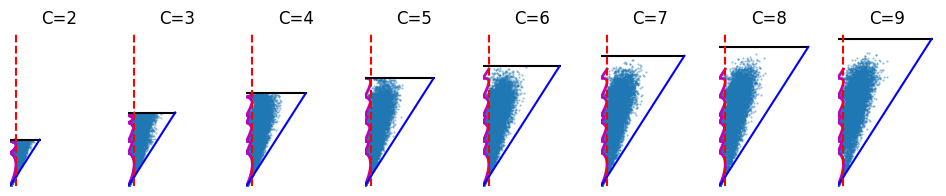

In [35]:

plt.figure(figsize=(15,2))
N = 10
for i,num_classes in enumerate(range(2,N)):
    num_ensemble = 5
    #num_classes = 5
    num_samples = 10000

    logit_std = 20
    corr1 = 0.5
    corr2 = 0.5


    logits = torch.randn(num_ensemble, num_samples, num_classes)*logit_std
    if corr1>0:
        logits = (torch.randn(1, num_samples, num_classes)*logit_std*corr1 + 
                logits*(1-corr1))
    if corr2>0:
        logits = (torch.randn(num_ensemble, num_samples, 1)*logit_std*corr2 + 
                logits*(1-corr2))
    probs = torch.softmax(logits, dim=2)
    AU,EU,TU = entu.get_theoretical_min_boundary(num_classes=num_classes, num_ensemble=num_ensemble)
    aleatoric, epistemic, total = uncertainties(probs)
    plt.subplot(1,N,i+1)
    plt.plot(aleatoric.numpy(), total.numpy(), '.',  markersize=1, alpha=0.5)
    plt.xlabel("Aleatoric Uncertainty")
    plt.ylabel("Total Uncertainty")
    plt.plot(AU, TU, 'm-', label="min AU", linewidth=2)
    max_tu = np.log(num_classes)
    plt.plot(np.linspace(0,max_tu,100),np.linspace(max_tu,max_tu,100), 'k-', label="x=y")
    plt.plot([0,max_tu],[0,max_tu], 'b', label="x=ln(2)")
    plt.axis("off")
    plt.axvline(x=np.log(2)/num_ensemble, color='r', linestyle='--', label='ln(2)')
    #plt.title(f"K={num_ensemble}")
    plt.title(f"C={num_classes}")
    plt.xlim(0,np.log(10))
    plt.ylim(0,np.log(10))


Text(0.5, 1.0, 'Uncertainty Space for C=2, N=10')

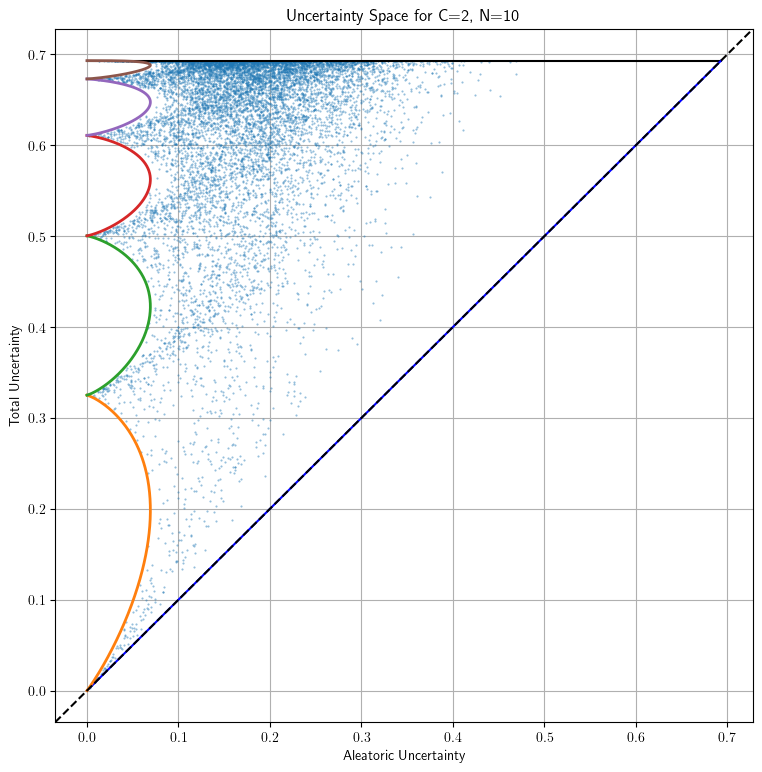

In [98]:
num_classes = 2
num_samples = 10000
num_ensemble = 10

logit_std = 10
corr1 = 0.3
corr2 = 0.3


logits = torch.randn(num_ensemble, num_samples, num_classes)*logit_std
if corr1>0:
    logits = (torch.randn(1, num_samples, num_classes)*logit_std*corr1 + 
              logits*(1-corr1))
if corr2>0:
    logits = (torch.randn(num_ensemble, num_samples, 1)*logit_std*corr2 + 
              logits*(1-corr2))
probs = torch.softmax(logits, dim=2)
#make float64
#probs = probs.double()
aleatoric, epistemic, total = uncertainties(probs)

plt.figure(figsize=(9,9))
max_tu = np.log(num_classes)

#plt.xscale('log')
#plt.yscale('log')
plot_TU = True
simplify_labels = False
AUs,EUs,TUs, Cws = entu.theoretical_boundaries_all(num_classes=num_classes, num_ensemble=num_ensemble,
                                                   include_eq_pairs=True,
                                                   detailed=False)
if plot_TU:
    plt.plot(aleatoric.numpy(), total.numpy(), '.',  markersize=1, alpha=0.5)
    plt.plot([0,max_tu],[max_tu,max_tu], 'k-')
    plt.plot([0,max_tu],[0,max_tu], 'b')
    plt.xlabel("Aleatoric Uncertainty")
    plt.ylabel("Total Uncertainty")
else:
    plt.plot(aleatoric.numpy(), epistemic.numpy(), '.',  markersize=1, alpha=0.5)
    plt.plot([0,max_tu],[max_tu,0], 'k-')
    plt.plot([0,max_tu],[0,0], 'b')
    plt.xlabel("Aleatoric Uncertainty")
    plt.ylabel("Epistemic Uncertainty")
for AU,EU,TU,cw in zip(AUs,EUs,TUs, Cws):
    label = ",".join([(f"{item}" if p==0 else f"\\underline{{{item}}}") for item, p in zip(cw[0], cw[1])])
    #remove all trailing ",0" and add "..."
    if simplify_labels:
        for i in range(num_classes):
            if label.endswith(",0"):
                label = label[:-2]
        label = f"[{label}, ...]"
    else:
        label = f"[{label}]"
    plt.plot(AU, TU if plot_TU else EU, "-", linewidth=2, label=label)
plt.rcParams["text.usetex"] = True
x_min,x_max = plt.xlim()
y_min,y_max = plt.ylim()
plt.plot([min(x_min,y_min), max(x_max,y_max)], [min(x_min,y_min), max(x_max,y_max)], 'k--', label="x=y")
plt.xlim(x_min,x_max)
plt.ylim(y_min,y_max)
#plt.legend(ncol=1)
plt.grid()
plt.title(f"Uncertainty Space for C={num_classes}, N={num_ensemble}")

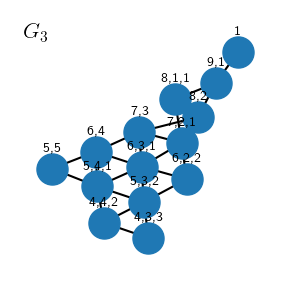

In [63]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
num_classes = 3
num_ensemble = 10
_,_,_, edges_raw = entu.theoretical_boundaries_all(num_classes=num_classes, num_ensemble=num_ensemble,
                                                   include_eq_pairs=False,
                                                   detailed=True)

G = nx.Graph()

for vertex, direction in edges_raw:
    vertex = np.asarray(vertex)
    direction = np.asarray(direction)

    a = tuple(vertex + np.maximum(direction, 0))
    b = tuple(vertex + np.maximum(-direction, 0))
    a = sorted(list(a), reverse=True)
    b = sorted(list(b), reverse=True)
    a_p = ",".join([str(int(x)) for x in a])
    b_p = ",".join([str(int(x)) for x in b])
    a_p = a_p.rstrip(",0")
    b_p = b_p.rstrip(",0")
    G.add_edge(a_p, b_p)

#pos = nx.spring_layout(G, seed=0)
pos = nx.kamada_kawai_layout(G)
plt.figure(figsize=(num_classes, num_classes))
nx.draw_networkx_edges(G, pos, width=1.5)
nx.draw_networkx_nodes(G, pos, node_size=500)
# 3: 
# Put vertex names slightly above the nodes
for node, (x, y) in pos.items():
    plt.annotate(node,
        xy=(x, y),xytext=(0, 10),
        textcoords="offset points",
        ha="center",va="bottom",
    )
#Write "G_K" in the top left corner
plt.text(0.05, 0.95, f"$G_{{{num_classes}}}$", transform=plt.gca().transAxes, fontsize=16, verticalalignment='top', horizontalalignment='left')
x_min,x_max = plt.xlim()
y_min,y_max = plt.ylim()
# add 10% space
plt.xlim(x_min - 0.1*(x_max-x_min), x_max + 0.1*(x_max-x_min))
plt.ylim(y_min - 0.1*(y_max-y_min), y_max + 0.1*(y_max-y_min))
plt.axis("off")
plt.tight_layout()
plt.show()

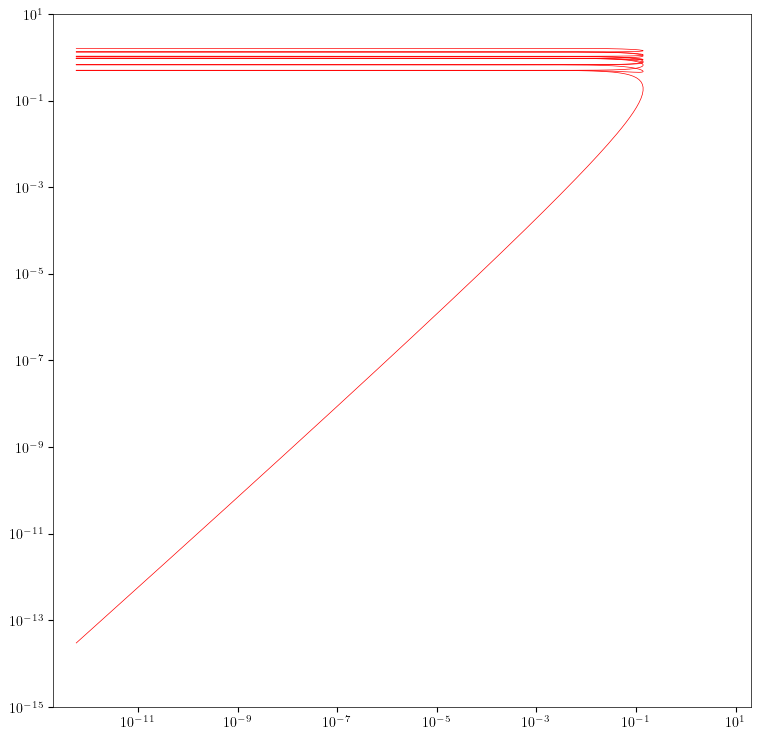

In [55]:
num_classes = 5
num_samples = 100000
num_ensemble = 5

fig, ax = plt.subplots(figsize=(9,9))

ax.set_xscale('log')
ax.set_yscale('log')
AUs,EUs,TUs, Cws = entu.theoretical_boundaries_all(num_classes=num_classes, num_ensemble=num_ensemble,
                                                   include_eq_pairs=False,
                                                   detailed=True)
for AU,EU,TU,cw in zip(AUs,EUs,TUs, Cws):
    ax.plot(AU, TU if plot_TU else EU, "-", linewidth=0.5, color="red")
ax.set_ylim(1e-15,1e1)
ax.set_xlim(2e-13,2e1)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.5)


# Make backgrounds transparent
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)
extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
fig.savefig("output.png", bbox_inches=extent, transparent=True, dpi=300)

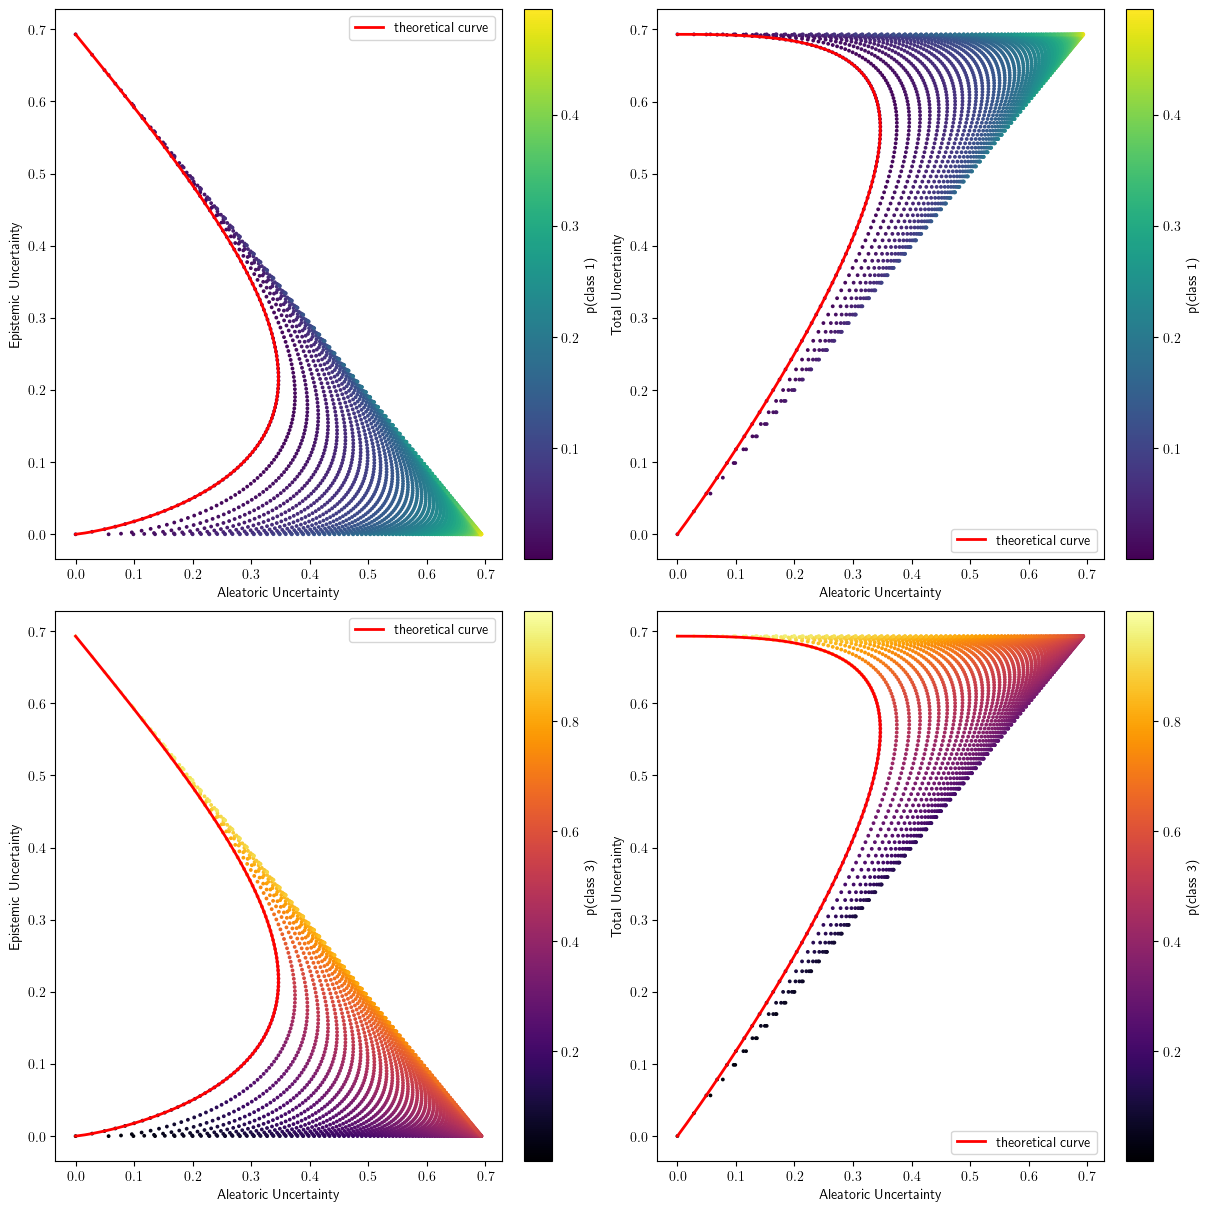

In [53]:
num_classes = 2
num_samples_per_dim = 100
num_ensemble = 2

eps = 1e-5
axis_probs = np.linspace(eps,1-eps,num_samples_per_dim)
p1,p3 = np.meshgrid(axis_probs, axis_probs)
p2 = 1-p1
p4 = 1-p3
probs12 = np.stack([p1,p2], axis=2).reshape(-1,2)
probs34 = np.stack([p3,p4], axis=2).reshape(-1,2)
probs = np.stack([probs12, probs34], axis=0)
mask = sum([(p1+p3)<=1, (p1+p4)<=1])==2
probs = probs[:,mask.flatten()]
#redefine p1,p3
p1 = probs[0,:,0]
p3 = probs[1,:,0]
aleatoric, epistemic, total = entu.uncertainties(torch.asarray(probs).float())
#to numpy
aleatoric, epistemic, total = aleatoric.numpy(), epistemic.numpy(), total.numpy()

plot_theo_curves = True
highlight_mask = None#np.logical_and(p1<2*eps,True)
s = 3
a = 1.0
fig, axs = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

# 1,1
sc = axs[0,0].scatter(aleatoric, epistemic, c=p1.flatten(), cmap='viridis', s=s, alpha=a)
axs[0,0].set_xlabel("Aleatoric Uncertainty"); axs[0,0].set_ylabel("Epistemic Uncertainty")
fig.colorbar(sc, ax=axs[0,0], label="p(class 1)")

# 1,2
sc = axs[0,1].scatter(aleatoric, total, c=p1.flatten(), cmap='viridis', s=s, alpha=a)
axs[0,1].set_xlabel("Aleatoric Uncertainty"); axs[0,1].set_ylabel("Total Uncertainty")
fig.colorbar(sc, ax=axs[0,1], label="p(class 1)")

# 2,1
sc = axs[1,0].scatter(aleatoric, epistemic, c=p3.flatten(), cmap='inferno', s=s, alpha=a)
axs[1,0].set_xlabel("Aleatoric Uncertainty"); axs[1,0].set_ylabel("Epistemic Uncertainty")
fig.colorbar(sc, ax=axs[1,0], label="p(class 3)")

# 2,2
sc = axs[1,1].scatter(aleatoric, total, c=p3.flatten(), cmap='inferno', s=s, alpha=a)
axs[1,1].set_xlabel("Aleatoric Uncertainty"); axs[1,1].set_ylabel("Total Uncertainty")
fig.colorbar(sc, ax=axs[1,1], label="p(class 3)")


S = np.linspace(eps,1-eps,200)
TU = -np.log(S/2)*(S/2)+ -np.log(1-S/2)*(1-S/2)
AU = (-np.log(S)*S - np.log(1-S)*(1-S))/2
EU = TU - AU
# highlights — always plot onto the same axes objects
for ax, yvals in [(axs[0,0], "epistemic"),
                    (axs[0,1], "total"),
                    (axs[1,0], "epistemic"),
                    (axs[1,1], "total")]:
    
    if highlight_mask is not None and np.any(highlight_mask):
        y_vals = epistemic if yvals == "epistemic" else total
        ax.scatter(
            aleatoric[highlight_mask], yvals[highlight_mask],
            facecolors='none', edgecolors='k', linewidths=1.0,
            s=s*10, alpha=0.7, zorder=5
        )
    if plot_theo_curves:
        y_vals = EU if yvals == "epistemic" else TU
        ax.plot(AU, y_vals, 'r-', linewidth=2, label="theoretical curve")
        ax.legend()


plt.show()



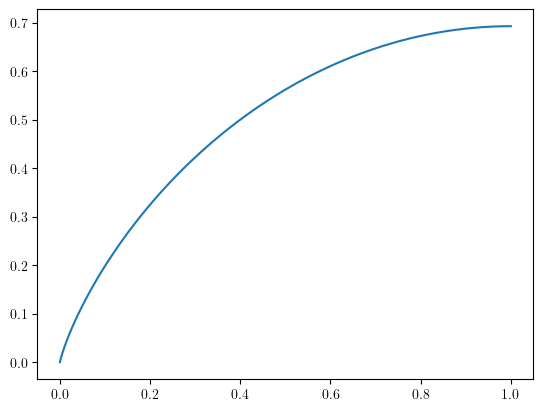

In [ ]:
def func(x):
    return (-np.log(x/2)*x/2 - np.log(1-x/2)*(1-x/2))
x = np.linspace(1e-8, 1-1e-8, 1000)
plt.plot(x, func(x))
plt.show()


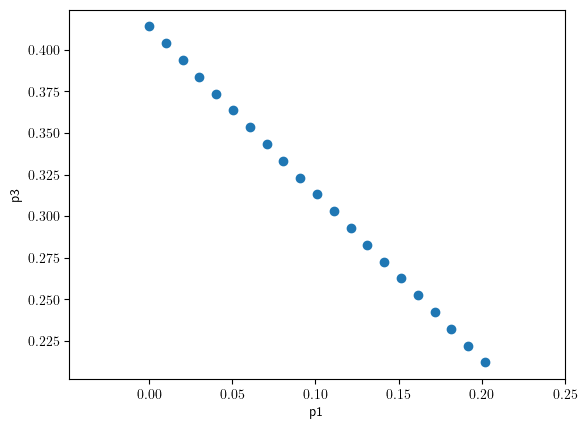

In [43]:
TU_v = 0.51
delta_v = 0.001

# print [p1,p3] for all pairs of points where |TU-TU_v| < delta_v
mask = np.abs(total - TU_v) < delta_v
p1p3 = np.stack([p1[mask], p3[mask]], axis=1)
plt.plot(p1p3[:,0], p1p3[:,1], 'o')
plt.xlabel("p1")
plt.ylabel("p3")
#set equal scaling
plt.axis('equal')
plt.show()

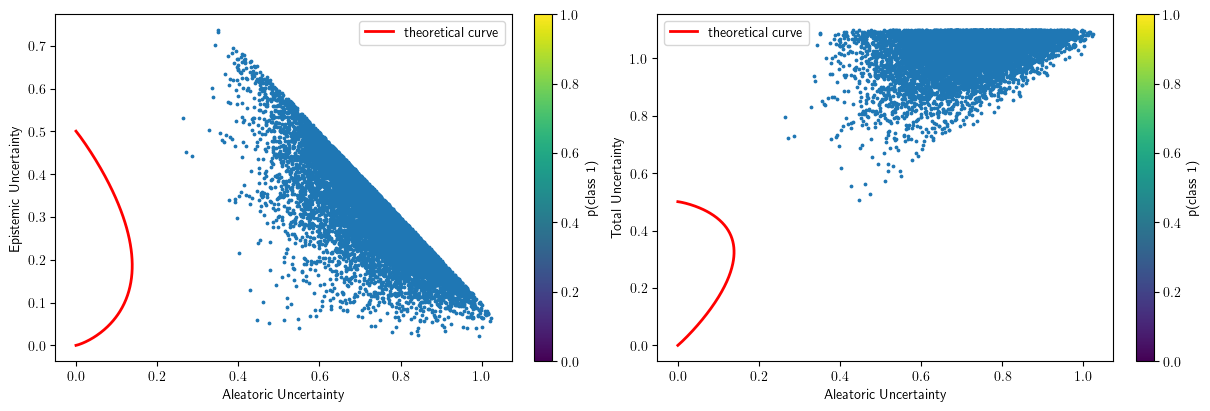

In [54]:
num_classes = 3
num_samples = 10000
num_ensemble = 5

eps = 1e-5
logit_std = 1.5
corr = 0.0

if corr>0:
    logits = (torch.randn(num_ensemble, num_samples, 1)*logit_std*corr + 
              torch.randn(num_ensemble, num_samples, num_classes)*logit_std*(1-corr))
else:
    logits = torch.randn(num_ensemble, num_samples, num_classes)*logit_std
probs = torch.softmax(logits, dim=2)

aleatoric, epistemic, total = uncertainties(probs)
aleatoric, epistemic, total = uncertainties(torch.asarray(probs))
#to numpy
aleatoric, epistemic, total = aleatoric.numpy(), epistemic.numpy(), total.numpy()

plot_theo_curves = True
highlight_mask = None#np.logical_and(p1<2*eps,True)
s = 3
a = 1.0
fig, axs = plt.subplots(1,2, figsize=(12, 4), constrained_layout=True)

# 1,1
sc = axs[0].scatter(aleatoric, epistemic, s=s, alpha=a)
axs[0].set_xlabel("Aleatoric Uncertainty"); axs[0].set_ylabel("Epistemic Uncertainty")
fig.colorbar(sc, ax=axs[0], label="p(class 1)")

# 1,2
sc = axs[1].scatter(aleatoric, total, s=s, alpha=a)
axs[1].set_xlabel("Aleatoric Uncertainty"); axs[1].set_ylabel("Total Uncertainty")
fig.colorbar(sc, ax=axs[1], label="p(class 1)")


S = np.linspace(eps,1-eps,200)
c = num_ensemble
TU = -np.log(S/c)*(S/c)+ -np.log(1-S/c)*(1-S/c)
AU = (-np.log(S)*S - np.log(1-S)*(1-S))/c
EU = TU - AU
# highlights — always plot onto the same axes objects
for ax, yvals in [(axs[0], "epistemic"),
                    (axs[1], "total")]:
    
    if highlight_mask is not None and np.any(highlight_mask):
        y_vals = epistemic if yvals == "epistemic" else total
        ax.scatter(
            aleatoric[highlight_mask], yvals[highlight_mask],
            facecolors='none', edgecolors='k', linewidths=1.0,
            s=s*10, alpha=0.7, zorder=5
        )
    if plot_theo_curves:
        y_vals = EU if yvals == "epistemic" else TU
        ax.plot(AU, y_vals, 'r-', linewidth=2, label="theoretical curve")
        ax.legend()


plt.show()


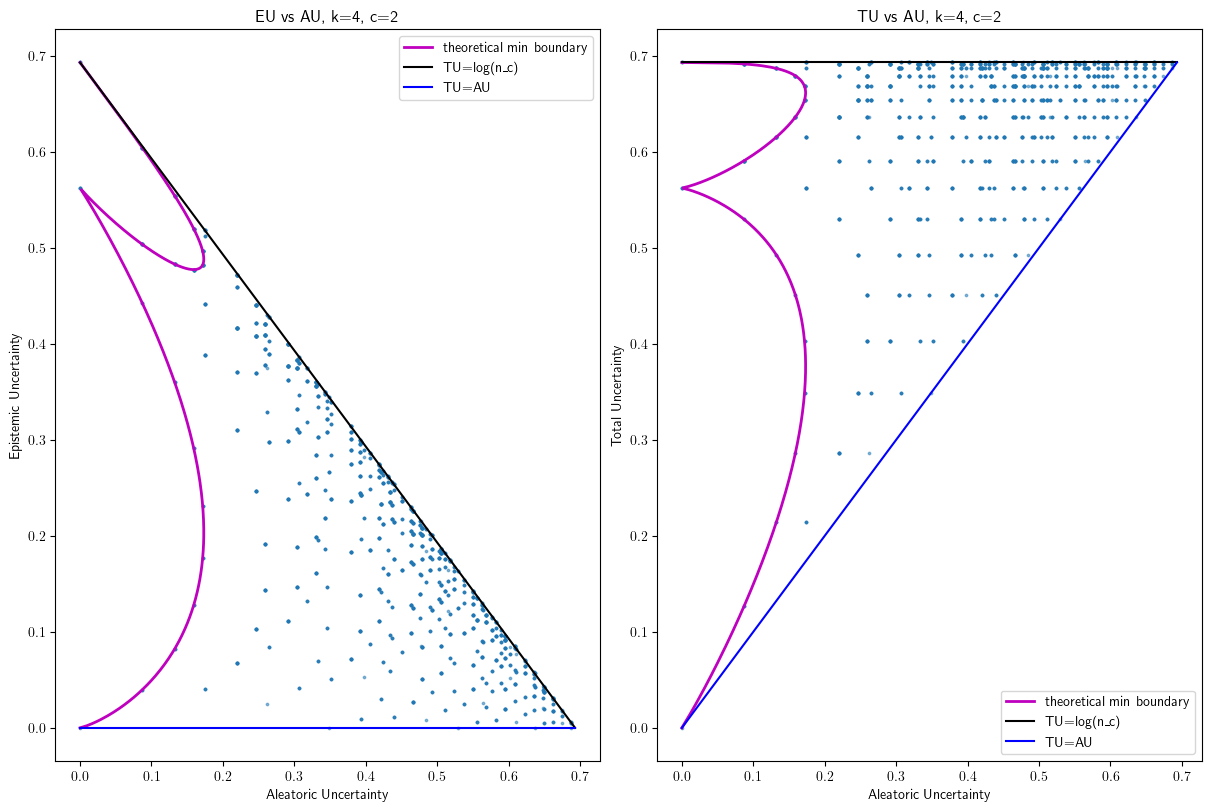

In [59]:


num_classes = 2
num_samples = 10000
num_ensemble = 4

if num_classes == 2:
    probs = entu.get_nd_probs(num_classes=num_classes, num_samples=num_samples, num_ensemble=num_ensemble, filter=True)
else:
    #simulate probs directly by sampling from Dirichlet, such that the third
    probs = entu.simulate_probs(num_samples=num_samples, 
                   num_classes=num_classes,num_ensemble=num_ensemble, 
                   logit_std = 20, 
                   corr=0.7)
aleatoric, epistemic, total = entu.uncertainties(probs)

plot_theo_curves_all = False
plot_theo_curves = False
plot_min_boundary = True
highlight_mask = None
logscale = False
s = 3
a = 0.5
fig, axs = plt.subplots(1,2, figsize=(12, 8), constrained_layout=True)

# 1,1
sc = axs[0].scatter(aleatoric, epistemic, s=s, alpha=a)
axs[0].set_xlabel("Aleatoric Uncertainty"); axs[0].set_ylabel("Epistemic Uncertainty")
# 1,2
sc = axs[1].scatter(aleatoric, total, s=s, alpha=a)
axs[1].set_xlabel("Aleatoric Uncertainty"); axs[1].set_ylabel("Total Uncertainty")


for ax, yvals in [(axs[0], "epistemic"),
                    (axs[1], "total")]:
    #ax.set_xlim(0.000,0.2)
    #ax.set_ylim(0.000,0.8)
    if logscale:
        ax.set_yscale('log')
        ax.set_xscale('log')
    if yvals == "epistemic":
        ax.set_title(f"EU vs AU, k={num_ensemble}, c={num_classes}")
    else:
        ax.set_title(f"TU vs AU, k={num_ensemble}, c={num_classes}")
    if highlight_mask is not None and np.any(highlight_mask):
        y_vals = epistemic if yvals == "epistemic" else total
        ax.scatter(
            aleatoric[highlight_mask], yvals[highlight_mask],
            edgecolors='k', linewidths=1.0,
            s=s*10, alpha=0.7, zorder=5
        )
    if plot_theo_curves:
        
        
        #AU, EU, TU = entu.theoretical_boundaries(200, c=num_ensemble, dim=0)
        AU, EU, TU = entu.theoretical_boundaries_binary(200, num_ensemble)
        y_vals = EU if yvals == "epistemic" else TU
        ax.plot(AU, y_vals, 'r-', label="theoretical curve")
        ax.legend()
    if plot_theo_curves_all:
        AUs, EUs, TUs, comps_with_S = entu.theoretical_boundaries_all(200, num_ensemble, num_classes)
        #get tab10 colors
        colors = plt.get_cmap('tab10').colors[1:]
        use_label = len(comps_with_S)<=20
        for AU, EU, TU, comp_S,i in zip(AUs, EUs, TUs, comps_with_S, range(len(AUs))):
            y_vals = EU if yvals == "epistemic" else TU
            label = "$("
            for n, is_S in zip(*comp_S):
                if is_S!=0:
                    l = f"{n}\u0332,"
                else:
                    l = f"{n},"
                label += l
                
            label = label[:-1]+")$" if use_label else None
            ax.plot(AU, y_vals, label=label, color=colors[i%len(colors)])
    if plot_min_boundary:
        AUs, EUs, TUs = entu.get_theoretical_min_boundary(num_classes=num_classes,num_ensemble=num_ensemble)
        y_vals = EUs if yvals == "epistemic" else TUs
        ax.plot(AUs, y_vals, 'm-', linewidth=2, label="theoretical min boundary")
        ax.legend()
        
    max_tu = np.log(num_classes)
    stop = 0 if yvals == "epistemic" else max_tu
    ax.plot(np.linspace(0,max_tu,100),np.linspace(max_tu,stop,100), 'k-', label="TU=log(n_c)")
    stop = max_tu if yvals == "total" else 0
    ax.plot(np.linspace(0,max_tu,100),np.linspace(0,stop,100), 'b-', label="TU=AU")
    ax.legend()
plt.show()

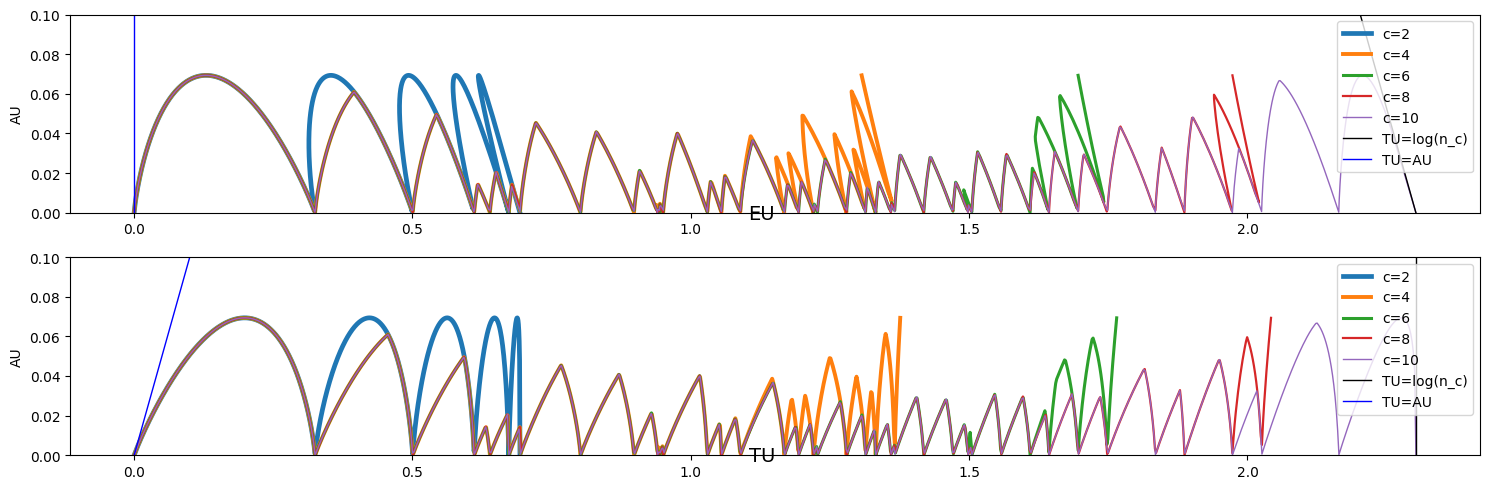

In [63]:

fig, axs = plt.subplots(2,1, figsize=(15, 5))

num_ensemble = 10

lw = 1
for ax, yvals in [(axs[0], "epistemic"),
                    (axs[1], "total")]: 
    for num_classes in range(2,12,2):
        AUs, EUs, TUs = entu.get_theoretical_min_boundary(num_classes=num_classes,num_ensemble=num_ensemble)
        y_vals = EUs if yvals == "epistemic" else TUs
        ax.plot(y_vals,AUs, '-', label="c="+str(num_classes),linewidth=lw+3-num_classes*0.3)
        max_au = np.log(min(1,num_ensemble/num_classes))
    
    max_tu = np.log(num_classes)
    stop = 0 if yvals == "epistemic" else max_tu
    ax.plot(np.linspace(max_tu,stop,100), np.linspace(0,max_tu,100),'k-', label="TU=log(n_c)", linewidth=lw)
    stop = max_tu if yvals == "total" else 0
    ax.plot(np.linspace(0,stop,100), np.linspace(0,max_tu,100),'b-', label="TU=AU", linewidth=lw)
    ax.set_ylim(0.000,0.1)
    ax.set_ylabel("AU")
    #ax.set_xlabel("EU" if yvals=="epistemic" else "TU")
    #simulate legend with ax.text since axis label takes so much space
    t = "EU" if yvals=="epistemic" else "TU"
    ax.text(0.5, -0.05, t, transform=ax.transAxes, fontsize=14,
        verticalalignment='bottom', horizontalalignment='right')
    ax.legend()
plt.tight_layout()

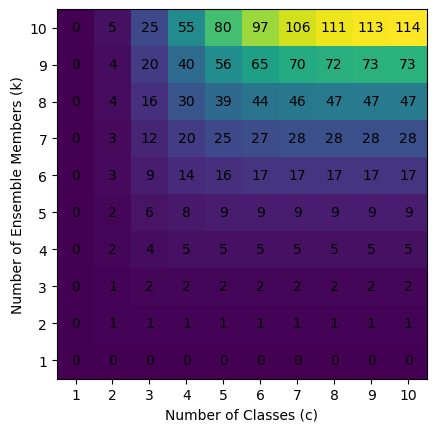

In [16]:
num_mat = []
for k in range(1,11):
    num_mat.append([])
    for c in range(1,11):
        comps_S = entu.theoretical_boundaries_all(2, num_ensemble=k, num_classes=c)[-1]
        num_mat[-1].append(len(comps_S))
plt.imshow(num_mat, cmap='viridis', origin='lower')
plt.xticks(np.arange(10), np.arange(1,11))
plt.yticks(np.arange(10), np.arange(1,11))
plt.xlabel("Number of Classes (c)")
plt.ylabel("Number of Ensemble Members (k)")
for i in range(10):
    for j in range(10):
        plt.text(j, i, str(num_mat[i][j]), ha='center', va='center', color='k')

In [ ]:
num_vec = []
for k in range(1,31):
    comps_S = entu.theoretical_boundaries_all(2, num_ensemble=k, num_classes=10)[-1]
    num_vec.append(len(comps_S))


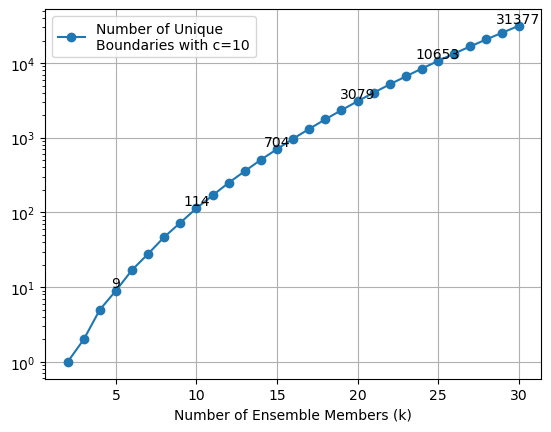

In [26]:
plt.plot(np.arange(2,31), num_vec[1:], 'o-', label="Number of Unique\nBoundaries with c=10")
plt.xlabel("Number of Ensemble Members (k)")
#plot text with numbers every 5 points
for i in range(4,30,5):
    plt.text(i+1, num_vec[i], str(num_vec[i]), ha='center', va='bottom')
plt.yscale('log')
plt.legend()
plt.grid()

In [ ]:
t = np.linspace(0,1,1000)
plt.plot(t,-t*np.log(t+1e-8), label="1 class entropy")
plt.axvline(1/np.e, color='k', linestyle='--', label="t=1/e")
plt.xlabel("t")
#plot point at (1/e, 1/e)
plt.scatter(1/np.e, 1/np.e*np.log(np.e), color='k')
y = -t*np.log(t+1e-8)-(1-t)*np.log((1-t)+1e-8)
plt.plot(t,y, label="2 class entropy")
plt.plot(t,y[::-1])

In [151]:

def get_not_3rd_or_more(partition):
    if len(partition) < 3:
        return [1 for _ in partition]
    else:
        a,b,c = partition[:-2], partition[1:-1], partition[2:]
        return [1,1]+[int(not (ai==bi==ci)) for ai,bi,ci in zip(a,b,c)]

def pairs_less_than_c(c):
    return [(a, b) for a in range(c) for b in range(a + 1, c)]

def get_comp_S(comp):
    is_3rd = get_not_3rd_or_more(comp)
    pairs = pairs_less_than_c(sum(is_3rd))
    #map pairs to non-zero indices of comp
    perm = lambda i: [j for j, x in enumerate(is_3rd) if x != 0][i]
    pairs = [(perm(i), perm(j)) for i, j in pairs]
    comps_S = [[0 for _ in range(len(is_3rd))] for _ in range(len(pairs))]
    for i, (a, b) in enumerate(pairs):
        comps_S[i][a] = 1
        comps_S[i][b] = -1
    return comps_S

k = num_ensemble = 5
c = num_classes = 5
comps = list(entu.unique_compositions(k-1, c))
print(comps)
comps_with_S = [[(comp, comp_S) for comp_S in get_comp_S(comp)] for comp in comps]
print([len(c) for c in comps_with_S])
print(comps_with_S)


[(4, 0, 0, 0, 0), (3, 1, 0, 0, 0), (2, 2, 0, 0, 0), (2, 1, 1, 0, 0), (1, 1, 1, 1, 0)]
[3, 6, 6, 10, 3]
[[((4, 0, 0, 0, 0), [1, -1, 0, 0, 0]), ((4, 0, 0, 0, 0), [1, 0, -1, 0, 0]), ((4, 0, 0, 0, 0), [0, 1, -1, 0, 0])], [((3, 1, 0, 0, 0), [1, -1, 0, 0, 0]), ((3, 1, 0, 0, 0), [1, 0, -1, 0, 0]), ((3, 1, 0, 0, 0), [1, 0, 0, -1, 0]), ((3, 1, 0, 0, 0), [0, 1, -1, 0, 0]), ((3, 1, 0, 0, 0), [0, 1, 0, -1, 0]), ((3, 1, 0, 0, 0), [0, 0, 1, -1, 0])], [((2, 2, 0, 0, 0), [1, -1, 0, 0, 0]), ((2, 2, 0, 0, 0), [1, 0, -1, 0, 0]), ((2, 2, 0, 0, 0), [1, 0, 0, -1, 0]), ((2, 2, 0, 0, 0), [0, 1, -1, 0, 0]), ((2, 2, 0, 0, 0), [0, 1, 0, -1, 0]), ((2, 2, 0, 0, 0), [0, 0, 1, -1, 0])], [((2, 1, 1, 0, 0), [1, -1, 0, 0, 0]), ((2, 1, 1, 0, 0), [1, 0, -1, 0, 0]), ((2, 1, 1, 0, 0), [1, 0, 0, -1, 0]), ((2, 1, 1, 0, 0), [1, 0, 0, 0, -1]), ((2, 1, 1, 0, 0), [0, 1, -1, 0, 0]), ((2, 1, 1, 0, 0), [0, 1, 0, -1, 0]), ((2, 1, 1, 0, 0), [0, 1, 0, 0, -1]), ((2, 1, 1, 0, 0), [0, 0, 1, -1, 0]), ((2, 1, 1, 0, 0), [0, 0, 1, 0, -1]), (


[]
[0.    0.125 0.25  0.375 0.5  ] [1.    0.875 0.75  0.625 0.5  ]


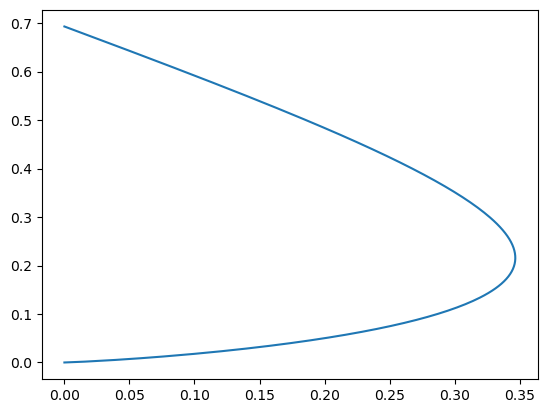

In [185]:
comp =   [1,0]
comp_S = [-1, 1]
S = np.linspace(0,1,5)
def entropy_from_comp(comp,comp_S,S):
    comp = np.array(comp)
    k = sum(comp)+1
    c = len(comp)
    prob = comp/k
    print()
    fixed_mask = [s == 0 for s in comp_S]
    entropy_fixed = entu.mxlogx(prob[fixed_mask]).sum()
    print(entu.mxlogx(prob[fixed_mask]))
    i0 = comp_S.index(1)
    i1 = comp_S.index(-1)
    p0 = prob[i0]+S/k
    p1 = prob[i1]+(1-S)/k
    print(p0,p1)
    ent = entu.mxlogx(p0)+entu.mxlogx(p1)+entropy_fixed
    return ent

AU,EU,TU = entu.theoretical_boundaries_binary(200, num_ensemble)

TU = entropy_from_comp(comp, comp_S, S)
plt.plot(AU,EU)

In [ ]:
lens = []
for i in range(1,15):
    k = c = i
    comps = list(entu.unique_compositions(k-1, c))
    comps_with_S = [[(comp, comp_S) for comp_S in get_comp_S(comp)] for comp in comps]
    lens.append(sum([len(c) for c in comps_with_S]))
    print(f"found {lens[-1]} S vectors for k=c={i}")

found 0 S vectors for k=c=1
found 1 S vectors for k=c=2
found 6 S vectors for k=c=3
found 12 S vectors for k=c=4
found 28 S vectors for k=c=5
found 48 S vectors for k=c=6
found 85 S vectors for k=c=7
found 134 S vectors for k=c=8
found 216 S vectors for k=c=9
found 322 S vectors for k=c=10
found 490 S vectors for k=c=11
found 708 S vectors for k=c=12
found 1030 S vectors for k=c=13
found 1451 S vectors for k=c=14


In [ ]:
comp = [0, 1, 1, 0, 0]

comps_S = get_comp_S(comp)
print(comps_S)

[[0, 1, -1, 0, 0]]


In [ ]:

def theoretical_boundaries_all(num_points,num_ensemble=2,num_classes=2):
    k = num_ensemble
    c = num_classes
    comps = list(entu.unique_compositions(k-1, c))
    
    # n1+n2=c-1
    S = np.linspace(0,1,num_points)
    AUs, EUs, TUs = [],[],[]
    for n1 in range(1,num_ensemble):
        TU = binary_entropy((n1-1+S)/c)
        AU = binary_entropy(S)/c
        EU = TU - AU
        AUs += AU.tolist()
        EUs += EU.tolist()
        TUs += TU.tolist()
    return AUs, EUs, TUs, comps

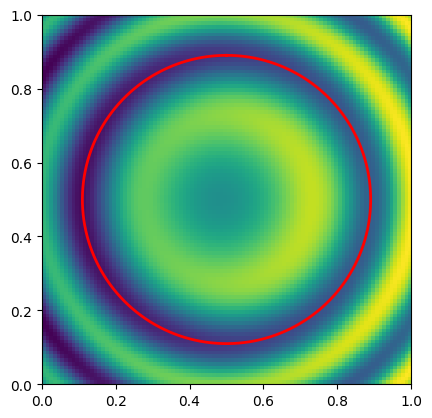

In [27]:
X, Y = np.meshgrid(np.linspace(0,1,100), np.linspace(0,1,100))

plt.imshow(np.sin(30*((X-0.5)**2+(Y-0.5)**2))+X, extent=(0,1,0,1), origin='lower', cmap='viridis')
t = np.linspace(0,2*np.pi,500)
#plot a circle
plt.plot(np.sin(t)*0.39+0.5, np.cos(t)*0.39+0.5, 'r-', linewidth=2)

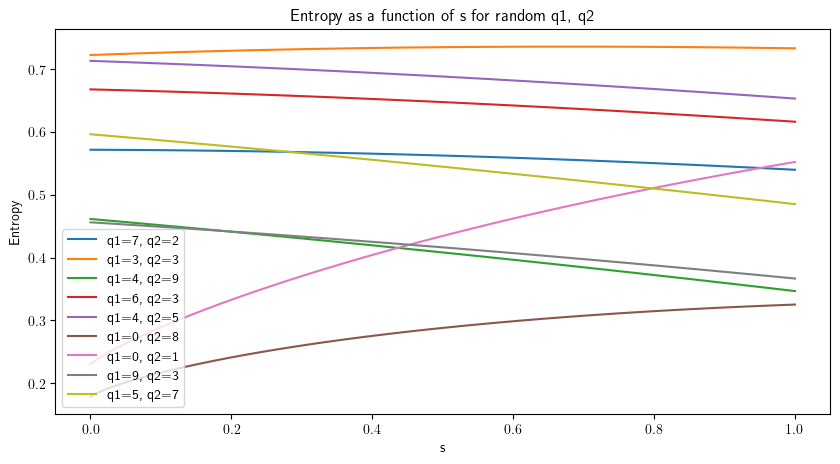

In [ ]:
N = 10
reps = 10
s = np.linspace(0,1,100)
def func(q1,q2,s):
    q1_hat = (q1+s)/N
    q2_hat = (q2+(1-s))/N
    return -q1_hat*np.log(q1_hat+1e-8)-q2_hat*np.log(q2_hat+1e-8)
plt.figure(figsize=(10,5))
for i in range(1,reps):
    q1 = np.random.randint(N)
    q2 = np.random.randint(N)
    plt.plot(s, func(q1,q2,s), label=f"q1={q1}, q2={q2}")
plt.xlabel("s")
plt.ylabel("Entropy")
plt.title("Entropy as a function of s for random q1, q2")
plt.legend()


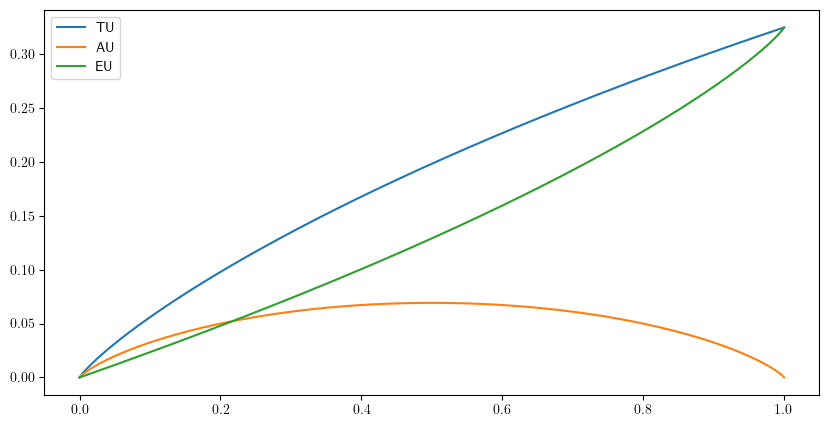

In [20]:
def binary_entropy(p):
    return -p*np.log(p+1e-8)-(1-p)*np.log(1-p+1e-8)

s = np.linspace(0,1,500)

N = 10

plt.figure(figsize=(10,5))
plt.plot(s, binary_entropy(s/N), label="TU")
plt.plot(s, binary_entropy(s)/N, label="AU")
plt.plot(s, binary_entropy(s/N)-binary_entropy(s)/N, label="EU")
plt.legend()

In [75]:
for seed in range(10):
    print(f'python train.py seed={120+seed} data.id_classes="01" time_append="-C2-01-Enet{seed}" data.id_only_head=True')

python train.py seed=120 data.id_classes="01" time_append="-C2-01-Enet0" data.id_only_head=True
python train.py seed=121 data.id_classes="01" time_append="-C2-01-Enet1" data.id_only_head=True
python train.py seed=122 data.id_classes="01" time_append="-C2-01-Enet2" data.id_only_head=True
python train.py seed=123 data.id_classes="01" time_append="-C2-01-Enet3" data.id_only_head=True
python train.py seed=124 data.id_classes="01" time_append="-C2-01-Enet4" data.id_only_head=True
python train.py seed=125 data.id_classes="01" time_append="-C2-01-Enet5" data.id_only_head=True
python train.py seed=126 data.id_classes="01" time_append="-C2-01-Enet6" data.id_only_head=True
python train.py seed=127 data.id_classes="01" time_append="-C2-01-Enet7" data.id_only_head=True
python train.py seed=128 data.id_classes="01" time_append="-C2-01-Enet8" data.id_only_head=True
python train.py seed=129 data.id_classes="01" time_append="-C2-01-Enet9" data.id_only_head=True


In [59]:
from pathlib import Path
# find paths similar to
# /home/jloch/Desktop/diff/functional/repo/cifar/logs/2026-08-27/16-46-36-C7-Enet4/val_logits.csv
# -> ./logs/2026-08-27/*-C7-Enet*/val_logits.csv
files = list(Path("/home/jloch/Desktop/diff/functional/repo/cifar/logs/2026-08-27").glob("*-C7-Enet*/val_logits.csv"))
files = list([str(f).replace("/home/jloch/Desktop/diff/functional/repo/cifar", ".") for f in files])
for file in files:
    print(f'python draw_calibration_hist.py "{file}" --recompute')

python draw_calibration_hist.py "./logs/2026-08-27/16-30-39-C7-Enet3/val_logits.csv" --recompute
python draw_calibration_hist.py "./logs/2026-08-27/15-58-46-C7-Enet1/val_logits.csv" --recompute
python draw_calibration_hist.py "./logs/2026-08-27/17-49-55-C7-Enet8/val_logits.csv" --recompute
python draw_calibration_hist.py "./logs/2026-08-27/16-14-43-C7-Enet2/val_logits.csv" --recompute
python draw_calibration_hist.py "./logs/2026-08-27/17-34-06-C7-Enet7/val_logits.csv" --recompute
python draw_calibration_hist.py "./logs/2026-08-27/17-18-13-C7-Enet6/val_logits.csv" --recompute
python draw_calibration_hist.py "./logs/2026-08-27/15-42-42-C7-Enet0/val_logits.csv" --recompute
python draw_calibration_hist.py "./logs/2026-08-27/18-05-55-C7-Enet9/val_logits.csv" --recompute
python draw_calibration_hist.py "./logs/2026-08-27/16-46-36-C7-Enet4/val_logits.csv" --recompute
python draw_calibration_hist.py "./logs/2026-08-27/17-02-27-C7-Enet5/val_logits.csv" --recompute


In [44]:
# list all logs in p
from pathlib import Path
import numpy as np
p = Path("/home/jloch/Desktop/diff/functional/repo/cifar/logs")
logit_files = list(p.glob("**/*.csv"))
logits = []
temp_scales = []
for f in logit_files:
    try:
        array = np.loadtxt(f, delimiter=",", dtype=str)[1:,:-1].astype(float)
        logits.append(array)
        temp_filename = str(f).replace("val_logits.csv", "optimal_temperature.txt")
        temp_scales.append(float(np.loadtxt(temp_filename, dtype=str)[-1]))
    except Exception as e:
        print(f"Error loading {f}: {e}")

logits = np.stack(logits, axis=0)
logits = torch.tensor(logits, dtype=torch.float32)
print(logits.shape)
print(temp_scales)

AU, EU, TU = entu.uncertainties(torch.softmax(logits, dim=2))

torch.Size([4, 10000, 10])
[2.4376466274261475, 2.4187231063842773, 2.5803070068359375, 2.453498363494873]


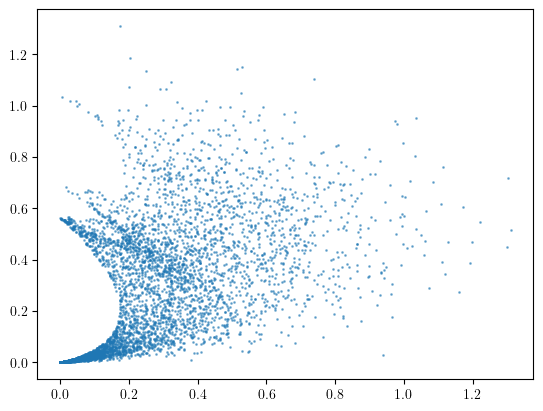

In [51]:
plt.scatter(AU.numpy(), EU.numpy(), s=1, alpha=0.5)
#plt.xlim(0,0.2), plt.ylim(0,0.2)
#plt.xscale('log'), plt.yscale('log')

In [68]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
for num_classes in range(2,15):
    num_ensemble = num_classes
    _,_,_, edges_raw = entu.theoretical_boundaries_all(num_classes=num_classes, num_ensemble=num_ensemble,
                                                       include_eq_pairs=False,
                                                       detailed=True)
    
    print(str(len(edges_raw))+",", end="")

1,2,5,9,17,28,47,73,114,170,253,365,525,

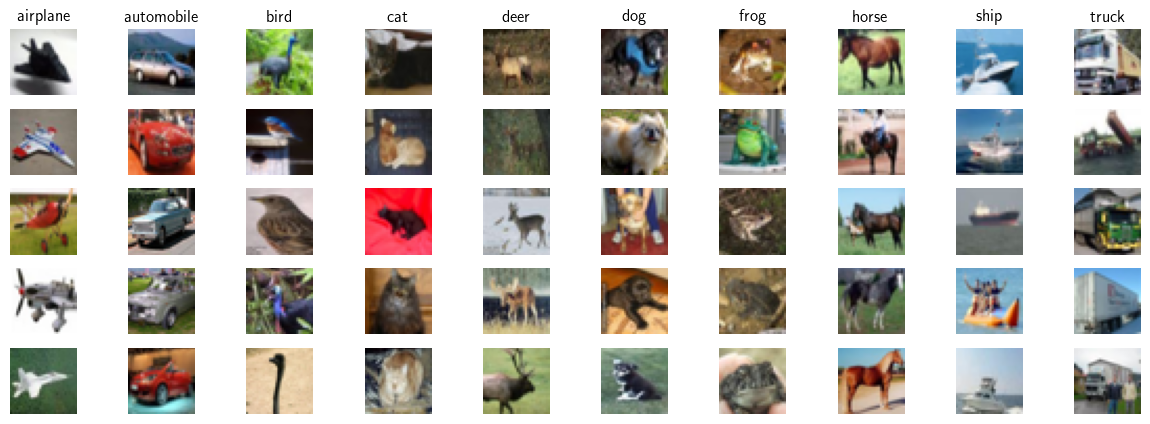

In [71]:
# load N images from each class and show as Nx10 grid
data_folder = "/home/jloch/Desktop/diff/functional/repo/cifar/data/cifar-10-batches-py"
N = 5
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def load_cifar_batch(filename):
    with open(filename, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
        data = batch[b'data']
        labels = batch[b'labels']
        data = data.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
        return data, labels

def load_cifar_data(data_folder):
    images = []
    labels = []
    for i in range(1, 6):
        batch_file = os.path.join(data_folder, f'data_batch_{i}')
        batch_images, batch_labels = load_cifar_batch(batch_file)
        images.append(batch_images)
        labels.append(batch_labels)
    images = np.concatenate(images)
    labels = np.concatenate(labels)
    return images, labels

images, labels = load_cifar_data(data_folder)

def show_images_grid(images, labels, N):
    fig, axes = plt.subplots(N, 10, figsize=(15, 5))
    for i in range(10):
        class_images = images[labels == i][:N]
        for j in range(N):
            if j==0:
                axes[j, i].set_title(classes[i])
            axes[j, i].imshow(class_images[j])
            axes[j, i].axis('off')
    plt.show()

show_images_grid(images, labels, N)

In [10]:
probs.shape

torch.Size([2, 10000, 2])

Probs on TU=0.5 line
tensor([[[5.5509e-04, 4.0310e-03, 9.9541e-01],
         [2.6721e-03, 9.9684e-01, 4.8721e-04],
         [2.6721e-03, 9.9684e-01, 4.8721e-04],
         [1.3856e-02, 9.8614e-01, 4.5338e-07],
         [9.9455e-01, 1.0097e-04, 5.3448e-03],
         [9.1619e-01, 6.4350e-02, 1.9458e-02],
         [3.5062e-03, 2.6358e-02, 9.7014e-01],
         [2.2786e-03, 6.8475e-03, 9.9087e-01],
         [1.9978e-01, 7.4445e-01, 5.5769e-02],
         [1.9978e-01, 7.4445e-01, 5.5769e-02]],

        [[6.3131e-04, 1.8137e-02, 9.8123e-01],
         [4.7887e-02, 9.4837e-01, 3.7422e-03],
         [4.7887e-02, 9.4837e-01, 3.7422e-03],
         [4.4584e-01, 5.4881e-01, 5.3450e-03],
         [7.7320e-01, 1.2621e-01, 1.0058e-01],
         [9.7584e-01, 1.7864e-02, 6.2962e-03],
         [1.6186e-02, 1.8220e-03, 9.8199e-01],
         [6.1698e-03, 4.4949e-02, 9.4888e-01],
         [1.4744e-02, 9.1399e-01, 7.1270e-02],
         [1.4744e-02, 9.1399e-01, 7.1270e-02]],

        [[2.4693e-03, 4.0370e-02, 9

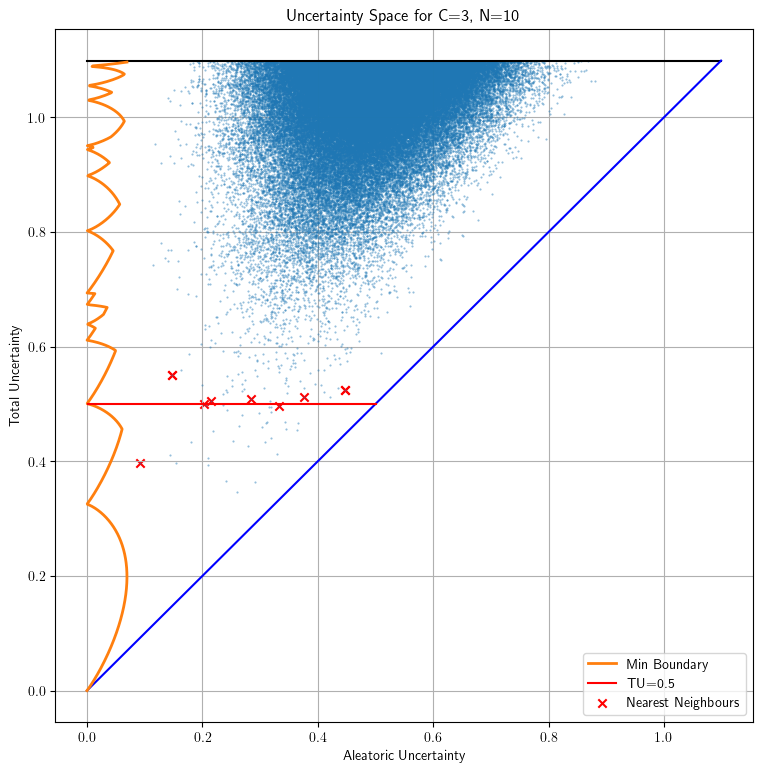

In [ ]:
num_classes = 2
num_samples = 100000
num_ensemble = 2

logit_std = 4
network_corr = 0.2
class_corr = 0.2

TU_v = 0.5

probs = entu.simulate_probs(num_ensemble=num_ensemble, num_samples=num_samples, num_classes=num_classes,
                             logit_std=logit_std, network_corr=network_corr, class_corr=class_corr)

#transform probs such that the mean prediction has C_0 >= C_1
mean_probs = probs.mean(dim=0)
swap_mask = mean_probs[:,0] < mean_probs[:,1]
#probs[:,swap_mask, :] = probs[:,swap_mask, :][:, :, [1, 0]]
AU,EU,TU = entu.get_theoretical_min_boundary(num_classes=num_classes, num_ensemble=num_ensemble,
                                                   detailed=False)
#interpolate AU at the place where TU equals TU_v
AU_v = np.interp(TU_v, TU, AU)

aleatoric, epistemic, total = entu.uncertainties(probs)
max_tu = np.log(num_classes)

points_v = np.linspace(AU_v,TU_v,10)
# find nearest neighbours in probs
nearest_neighbours = []
for point in points_v:
    distances = np.sqrt((aleatoric.numpy() - point)**2 + (total.numpy() - TU_v)**2)
    nearest_neighbours.append(np.argmin(distances))

plt.figure(figsize=(9,9))

plt.plot(aleatoric.numpy(), total.numpy(), '.',  markersize=1, alpha=0.5)
plt.plot([0,max_tu],[max_tu,max_tu], 'k-')
plt.plot([0,max_tu],[0,max_tu], 'b')
plt.xlabel("Aleatoric Uncertainty")
plt.ylabel("Total Uncertainty")
plt.plot(AU, TU, "-", linewidth=2, label="Min Boundary")
plt.plot([AU_v,TU_v], [TU_v,TU_v], "r", label=f"TU={TU_v}")
plt.legend()
plt.rcParams["text.usetex"] = True
plt.grid()
plt.scatter(aleatoric.numpy()[nearest_neighbours], total.numpy()[nearest_neighbours], c='r', marker='x', label='Nearest Neighbours')
plt.legend()
plt.title(f"Uncertainty Space for C={num_classes}, N={num_ensemble}")
print(f"Probs on TU={TU_v} line")
print(probs[:,nearest_neighbours,:])

In [31]:
print(probs[:,nearest_neighbours,:].shape)

torch.Size([2, 10, 2])


In [15]:
probs.sum(0)[:5]

tensor([[0.9056, 1.0944],
        [1.3102, 0.6898],
        [0.7198, 1.2802],
        [1.3025, 0.6975],
        [0.6938, 1.3062]])

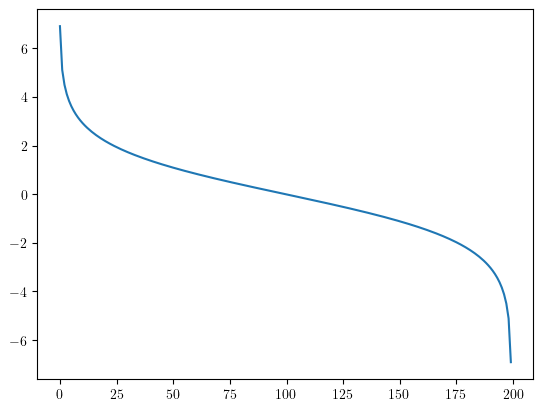

In [69]:
eps = 1e-3
t = np.linspace(0+eps,1-eps,200)
plt.plot(np.log((1-t)/t))

In [82]:
for seed in range(10):
    print(f'python train.py seed={120+seed} data.id_classes="0123456" time_append="-C7-save10-Enet{seed}" data.id_only_head=True training.save_logits_every_n_epochs=10')

python train.py seed=120 data.id_classes="0123456" time_append="-C7-save10-Enet0" data.id_only_head=True training.save_logits_every_n_epochs=10
python train.py seed=121 data.id_classes="0123456" time_append="-C7-save10-Enet1" data.id_only_head=True training.save_logits_every_n_epochs=10
python train.py seed=122 data.id_classes="0123456" time_append="-C7-save10-Enet2" data.id_only_head=True training.save_logits_every_n_epochs=10
python train.py seed=123 data.id_classes="0123456" time_append="-C7-save10-Enet3" data.id_only_head=True training.save_logits_every_n_epochs=10
python train.py seed=124 data.id_classes="0123456" time_append="-C7-save10-Enet4" data.id_only_head=True training.save_logits_every_n_epochs=10
python train.py seed=125 data.id_classes="0123456" time_append="-C7-save10-Enet5" data.id_only_head=True training.save_logits_every_n_epochs=10
python train.py seed=126 data.id_classes="0123456" time_append="-C7-save10-Enet6" data.id_only_head=True training.save_logits_every_n_ep

torch.Size([10, 10000, 10])


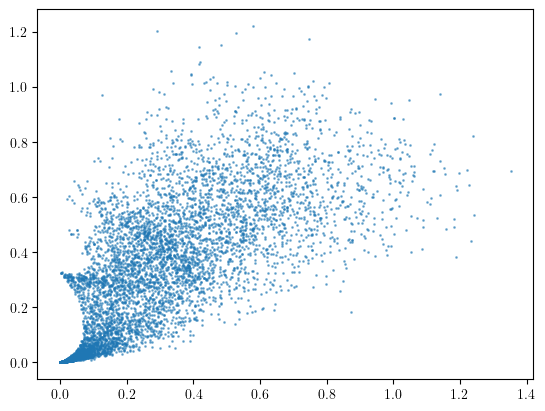

In [112]:
# list all logs in p
from pathlib import Path
import numpy as np
p = Path("/home/jloch/Desktop/diff/functional/repo/cifar/logs")
logit_files = list(p.glob("**/*C7-save10-Enet*/val_logits_epoch_200.csv"))
logits = []
for f in logit_files:
    array = np.loadtxt(f, delimiter=",", dtype=str)[1:,:-1].astype(float)
    logits.append(array)
gt = np.loadtxt(f, delimiter=",", dtype=str)[1:,-1].astype(float)
logits = np.stack(logits, axis=0)
logits = torch.tensor(logits, dtype=torch.float32)
print(logits.shape)

AU, EU, TU = entu.uncertainties(torch.softmax(logits, dim=2))
plt.scatter(AU.numpy(), EU.numpy(), s=1, alpha=0.5)

In [149]:
import glob
glob.glob("/home/jloch/Desktop/diff/functional/repo/cifar/logs/*/*-save10-ENetb2-*/logits/val_logits_epoch_020.csv")

['/home/jloch/Desktop/diff/functional/repo/cifar/logs/2026-09-05/10-20-39-C7-save10-ENetb2-pre-7/logits/val_logits_epoch_020.csv',
 '/home/jloch/Desktop/diff/functional/repo/cifar/logs/2026-09-05/09-35-25-C7-save10-ENetb2-pre-3/logits/val_logits_epoch_020.csv',
 '/home/jloch/Desktop/diff/functional/repo/cifar/logs/2026-09-05/10-43-15-C7-save10-ENetb2-pre-9/logits/val_logits_epoch_020.csv',
 '/home/jloch/Desktop/diff/functional/repo/cifar/logs/2026-09-05/09-58-03-C7-save10-ENetb2-pre-5/logits/val_logits_epoch_020.csv',
 '/home/jloch/Desktop/diff/functional/repo/cifar/logs/2026-09-05/09-46-47-C7-save10-ENetb2-pre-4/logits/val_logits_epoch_020.csv',
 '/home/jloch/Desktop/diff/functional/repo/cifar/logs/2026-09-05/09-01-22-C7-save10-ENetb2-pre-0/logits/val_logits_epoch_020.csv',
 '/home/jloch/Desktop/diff/functional/repo/cifar/logs/2026-09-05/09-24-05-C7-save10-ENetb2-pre-2/logits/val_logits_epoch_020.csv',
 '/home/jloch/Desktop/diff/functional/repo/cifar/logs/2026-09-05/10-31-57-C7-save10

In [156]:
import yaml
import glob
from pathlib import Path
import torch
import numpy as np

def load_ens_logits(file_paths, only_id_gts=True, apply_temp=False):
    """loads ensemble logits from multiple CSV files"""
    if isinstance(file_paths,str):
        file_paths = list(glob.glob(file_paths))
    ens_out = []
    for file_path in file_paths:
        ens_out.append(load_logits(file_path, only_id_gts=only_id_gts, apply_temp=apply_temp))
    ens_out = {k: [d[k] for d in ens_out] for k in ens_out[0]}
    assert all(torch.equal(ens_out["id_classes"][0], d) for d in ens_out["id_classes"])
    for k in ens_out.keys():
        if k in ["logits", "probs"]:
            ens_out[k] = torch.stack(ens_out[k], dim=0)
        elif k in ["gt", "id_classes"]:
            ens_out[k] = ens_out[k][0]
    return ens_out

def load_logits(file_path, only_id_gts=True, apply_temp=False):
    """loads logits from a CSV file, reads id_classes from the associated config.
    The config is in p.parent.parent/".hydra" / "config.yaml"
    if the parent name is "logits", otherwise just p.parent
    """
    out = {"logits": None, 
           "probs": None,
           "temp": None,
           "id_classes": None,
           "gt": None}
    raw_logits = np.loadtxt(file_path, delimiter=",", dtype=str)
    out["logits"] = torch.tensor(raw_logits[1:,:-1].astype(float))
    out["gt"] = torch.tensor(raw_logits[1:,-1].astype(int))
    # load config
    if Path(file_path).parent.name == "logits":
        config_path = Path(file_path).parent.parent / ".hydra" / "config.yaml"
        temp_path = Path(file_path).parent.parent / "optimal_temperature.txt"
    else:
        config_path = Path(file_path).parent / ".hydra" / "config.yaml"
        temp_path = Path(file_path).parent / "optimal_temperature.txt"
    if temp_path.exists():
        out["temp"] = float(np.loadtxt(temp_path, dtype=str)[-1])
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    out["id_classes"]  = torch.tensor([int(x) for x in config["data"]["id_classes"]])
    if only_id_gts:
        mask = np.isin(out["gt"], out["id_classes"])
        out["logits"] = out["logits"][mask]
        out["gt"] = out["gt"][mask]
    if apply_temp:
        if out["temp"] is not None:
            out["logits"] = out["logits"] / out["temp"]
    id_class_mask = [i not in out["id_classes"] for i in range(out["logits"].shape[-1])]
    out["probs"] = torch.zeros_like(out["logits"])
    out["probs"][:,id_class_mask] = torch.softmax(out["logits"][:,id_class_mask], dim=-1)
    return out
#file_path = "/home/jloch/Desktop/diff/functional/repo/cifar/logs/2026-09-04/19-35-56-C7-save10-ENetb2-9/logits/val_logits_epoch_020.csv"
file_path = "./cifar/logs/*/*-C7-save10-ENetb4-*/logits/val_logits_epoch_200.csv"
for k,v in load_ens_logits(file_path).items():
    if k in ["logits", "probs", "gt"]:
        print(k, v.shape)
    else:
        print(k, v)

logits torch.Size([10, 7000, 10])
probs torch.Size([10, 7000, 10])
temp [None, None, None, None, None, None, None, None, None, None]
id_classes tensor([0, 1, 2, 3, 4, 5, 6])
gt torch.Size([7000])


In [112]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable

ignore_labels = list(range(7,10))

if gt is not None:
    mask = np.isin(gt, ignore_labels)
    logits = logits[:, ~mask, :]
    gt = gt[~mask]
id_mask = [i not in ignore_labels for i in range(logits.shape[-1])]
p = np.zeros_like(logits)
p[:,:,id_mask] = torch.softmax(logits[:,:,id_mask], dim=-1)

C = 10-len(ignore_labels)
N = len(logits)
plot_TU = True
plot_xy = False
simplify_labels = False
plot_curves = True
alpha = 0.7
lw = 2
do_unbubble = False

max_tu = np.log(C)
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 6))

AU, EU, TU = entu.uncertainties(p)


#linearly interpolate colors between C0 and C1 for each point based on the correct ratio
#conver to numpy if not already
if torch.is_tensor(AU):
    AU = AU.numpy()
if torch.is_tensor(EU):
    EU = EU.numpy()
if torch.is_tensor(TU):
    TU = TU.numpy()
for i, ax in enumerate(axs):
    if i==1:
        AU, EU, TU = entu.unbubble(AU, TU, C, N)
    if plot_TU:
        if gt is None:
            ax.plot(AU, TU, '.',  markersize=1, alpha=alpha, linewidth=lw)
        else:
            viridis = plt.get_cmap("viridis")
            cmap = [viridis(x) for x in np.linspace(0, 1, N+1)]

            # Number of ensemble members predicting the correct class
            preds = torch.argmax(logits, dim=-1)
            correct = (preds == torch.tensor(gt, dtype=torch.int64)).sum(dim=0)

            # Map correct-count to one of the 10 viridis colors
            idx = np.round(correct.numpy()).astype(int)
            cmap2 = [cmap[i] for i in idx]

            ax.scatter(
                AU, TU,
                c=cmap2, s=5, alpha=0.3
            )
            cmap = plt.get_cmap("viridis", N + 1)
            norm = BoundaryNorm(np.arange(-0.5, N + 1.5), N + 1)

            plt.colorbar(
                ScalarMappable(norm=norm, cmap=cmap),
                ax=ax,
                ticks=np.arange(N + 1),
                label="Number correct"
            )

        ax.plot([0,max_tu],[max_tu,max_tu], 'k-', alpha=alpha, linewidth=lw)#, label=r"TU$\leq\log(C)$")
        ax.plot([0,max_tu],[0,max_tu], 'b', alpha=alpha, linewidth=lw)#, label=r"TU$\geq$AU")
        ax.set_xlabel("AU")
        ax.set_ylabel("TU")
    else:
        ax.plot([0,max_tu],[max_tu,0], 'k-', label=r"TU$\leq\log(C)$", alpha=alpha, linewidth=lw)
        ax.plot([0,max_tu],[0,0], 'b', label=r"TU$\geq$AU", alpha=alpha, linewidth=lw)
        ax.set_xlabel("AU")
        ax.set_ylabel("EU")
        if gt is None:
            ax.plot(AU, EU, '.',  markersize=1, alpha=alpha, linewidth=lw)
        else:
            viridis = plt.get_cmap("viridis")
            cmap = [viridis(x) for x in np.linspace(0, 1, N+1)]

            # Number of ensemble members predicting the correct class
            preds = torch.argmax(logits, dim=-1)
            correct = (preds == torch.tensor(gt, dtype=torch.int64)).sum(dim=0)

            # Map correct-count to one of the 10 viridis colors
            idx = np.round(correct.numpy()).astype(int)
            cmap2 = [cmap[i] for i in idx]

            ax.scatter(
                AU, EU,
                c=cmap2, s=5, alpha=0.3
            )
            cmap = plt.get_cmap("viridis", N + 1)
            norm = BoundaryNorm(np.arange(-0.5, N + 1.5), N + 1)

            plt.colorbar(
                ScalarMappable(norm=norm, cmap=cmap),
                ax=ax,
                ticks=np.arange(N + 1),
                label="Number correct"
            )
    if plot_xy:
        x_min,x_max = ax.get_xlim()
        y_min,y_max = ax.get_ylim()
        ax.plot([min(x_min,y_min), max(x_max,y_max)], [min(x_min,y_min), max(x_max,y_max)], 'k--', label="x=y")
        ax.set_xlim(x_min,x_max)
        ax.set_ylim(y_min,y_max)


    AUb,EUb,TUb = entu.get_theoretical_min_boundary(num_classes=C, num_ensemble=N,
                                                    detailed=False,
                                                    interp=True)

    ax.plot(AUb, TUb if plot_TU else EUb, "m-", linewidth=2, label=f"Infeasible Boundary (N={N})")

    #ax.set_xscale('log'), ax.set_yscale('log')
    #ax.set_xlim(1e-3, 1.05*max_tu)
    #ax.set_ylim(1e-3, 1.05*max_tu)
    #ax.set_xlim(-0.0*max_tu, 1.05*max_tu)
    #ax.set_ylim(-0.0*max_tu, 1.05*max_tu)
    #ax.set_xlim(-0.0*max_tu, 0.4*max_tu)
    #ax.set_ylim(-0.0*max_tu, 0.4*max_tu)
    plt.grid()
    ax.legend(ncol=1)
#plt.savefig(f"../writing/images/triangles4.png", dpi=300, bbox_inches='tight')

NameError: name 'gt' is not defined

In [134]:
np.log(7)

np.float64(1.9459101490553132)

In [ ]:
#print index of point with max TU
max_TU_index = np.argmax(TU)
#print probabilities
p_max_TU = p[:, max_TU_index, :]
AUh, EUh, TUh = entu.uncertainties(p_max_TU[:,None])
print(AUh, EUh, TUh)
#print(p_max_TU)
print(np.array2string(p_max_TU.numpy(), formatter={'float_kind': lambda x: f'{x:.3f}'}))

print(np.array2string(p_max_TU.numpy().mean(axis=0), formatter={'float_kind': lambda x: f'{x:.3f}'}))

tensor([1.1408]) tensor([0.9742]) tensor([2.1150])
tensor([2.1150])
[[0.410 0.041 0.033 0.098 0.117 0.018 0.049 0.078 0.078 0.078]
 [0.034 0.381 0.003 0.382 0.001 0.004 0.121 0.024 0.024 0.024]
 [0.003 0.065 0.157 0.046 0.087 0.064 0.396 0.061 0.061 0.061]
 [0.139 0.138 0.058 0.004 0.172 0.092 0.218 0.060 0.060 0.060]
 [0.000 0.000 0.000 0.015 0.931 0.002 0.031 0.007 0.007 0.007]
 [0.575 0.411 0.003 0.000 0.000 0.002 0.002 0.002 0.002 0.002]
 [0.014 0.179 0.003 0.096 0.309 0.015 0.261 0.041 0.041 0.041]
 [0.001 0.924 0.000 0.000 0.065 0.006 0.001 0.001 0.001 0.001]
 [0.014 0.000 0.962 0.000 0.004 0.000 0.006 0.004 0.004 0.004]
 [0.000 0.044 0.003 0.024 0.019 0.864 0.000 0.015 0.015 0.015]]
[0.119 0.218 0.122 0.066 0.170 0.107 0.108 0.029 0.029 0.029]


In [ ]:
#resnet18 (11.18m), resnet50 (23.53m), efficientnet_b0 (4.02m), vit_b16 (85.81m)
#models = ["resnet18", "resnet50", "vit_b16"]
#model_names = ["ResNet-18", "ResNet-50", "ViT-B16"]
models = [f"efficientnet_b{i}" for i in [2,4,6]]
model_names = [f"ENetb{i}" for i in [2,4,6]]
for model, model_name in zip(models, model_names):
    for seed in range(10):
        print(f'python train.py seed={120+seed} data.id_classes="0123456" time_append="-C7-save10-{model_name}-{seed}" data.id_only_head=True training.save_logits_every_n_epochs=10 model.arch="{model}" model.pretrained=False')
for model, model_name in zip(models, model_names):
    for seed in range(10):
        print(f'python train.py seed={120+seed} data.id_classes="0123456" time_append="-C7-save10-{model_name}-pre-{seed}" data.id_only_head=True training.save_logits_every_n_epochs=5 model.arch="{model}" model.pretrained=True training.epochs=100')

Text(0.5, 1.0, 'ENetb4, Epoch 80 (From scratch)')

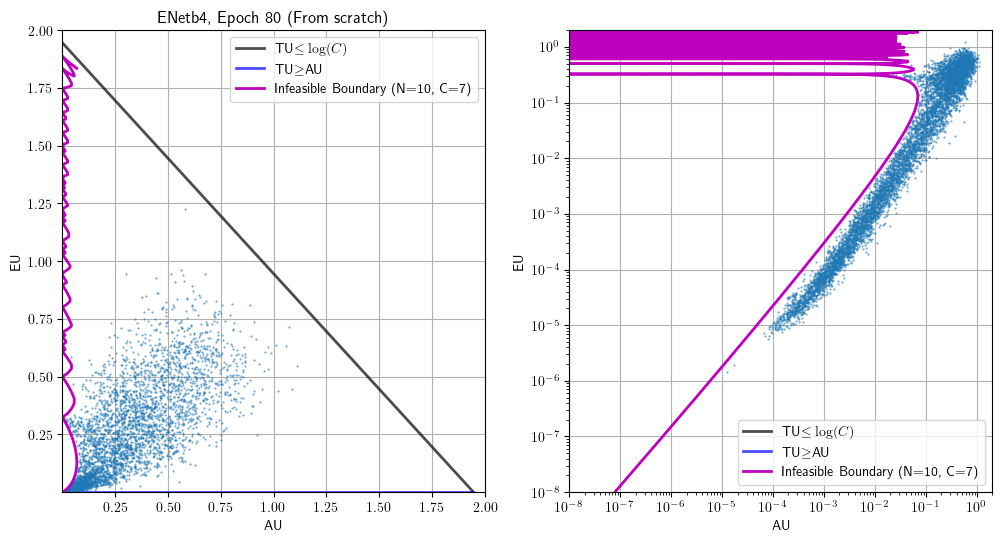

In [111]:
ens_logits = entu.load_ens_logits(file_paths)
ens_logits["probs"] = ens_logits["probs"].float()
#ens_logits["paths"]
fig, axs = entu.ensemble_plot_log(ens_logits,plot_boundary=1,interp=0, limits=[(1e-8,2),(1e-8,2)],gt_colormap=0)
title = f"ENetb{enet_b}, Epoch {epoch}"
title += " (Pretrained)" if pretrained else " (From scratch)"
axs[0].set_title(title)

(8463,) (8463,) (8463,)


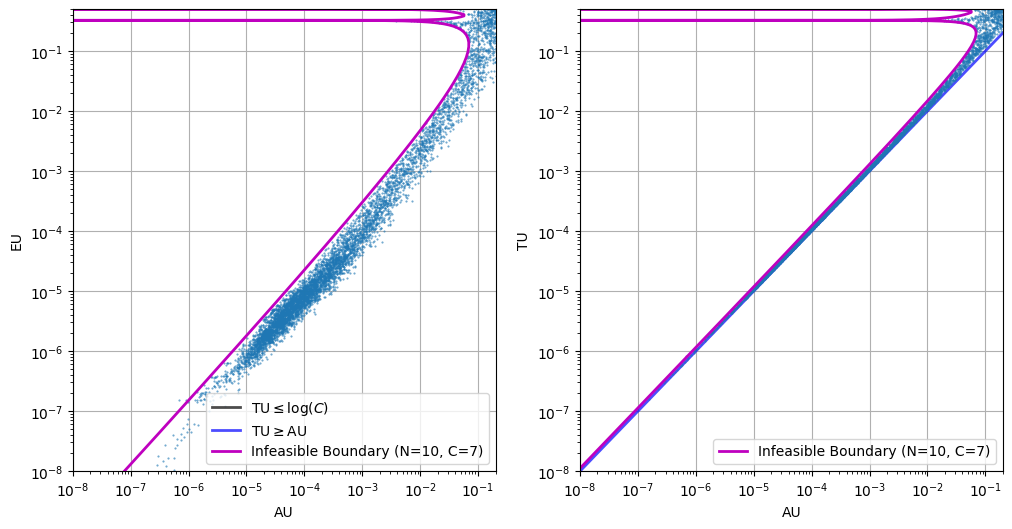

In [85]:
entu.ensemble_plot(ens_logits,limits=[[1e-8, 0.2], [1e-8, 0.5], [1e-8,0.5]],log=True,interp=False,detailed=True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
# repo/cifar/logs/2026-09-08/06-17-07-C7-e400-ENetb6-0
p = Path("/home/jloch/Desktop/diff/functional/repo/cifar/logs")
#logit_files = list(p.glob("**/*-C2-01-Enet*/*.csv"))
logit_files = list(p.glob("**/*-C7-save10-ENetb0-*/val_logits.csv"))
logit_files = sorted(logit_files)[:3]
logits = []
temp_scales = []
gt = None
for f in logit_files:
    try:
        array = np.loadtxt(f, delimiter=",", dtype=str)[1:,:-1].astype(float)
        logits.append(array)
        if gt is None:
            gt = np.loadtxt(f, delimiter=",", dtype=str)[1:,-1].astype(int)
        temp_filename = str(f).replace("val_logits.csv", "optimal_temperature.txt")
        temp_scales.append(float(np.loadtxt(temp_filename, dtype=str)[-1]))
    except Exception as e:
        print(f"Error loading {f}: {e}")
apply_temp = False
logits = np.stack(logits, axis=0)

if apply_temp:
    temp = np.array(temp_scales).reshape(-1, 1, 1)
    logits = logits / temp
logits = torch.tensor(logits, dtype=torch.float32)

ignore_labels = list(range(7,10))

#ignore labels using gt indices
if gt is not None:
    mask = np.isin(gt, ignore_labels)
    logits = logits[:, ~mask, :]
    gt = gt[~mask]
#crop_ood = False
#if crop_ood:
#    logits = logits[:, :, :(10-len(ignore_labels))]
p = torch.softmax(logits, dim=-1)

C = 10-len(ignore_labels)
N = len(logits)
plot_TU = True
plot_xy = False
simplify_labels = False
plot_curves = True
alpha = 0.7
lw = 2
do_unbubble = False

max_tu = np.log(C)
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 6))

AU, EU, TU = entu.uncertainties(p)


#linearly interpolate colors between C0 and C1 for each point based on the correct ratio
#conver to numpy if not already
if torch.is_tensor(AU):
    AU = AU.numpy()
if torch.is_tensor(EU):
    EU = EU.numpy()
if torch.is_tensor(TU):
    TU = TU.numpy()
for i, ax in enumerate(axs):
    if i==1:
        AU, EU, TU = entu.unbubble(AU, TU, C, N)
    if plot_TU:
        if gt is None:
            ax.plot(AU, TU, '.',  markersize=1, alpha=alpha, linewidth=lw)
        else:
            viridis = plt.get_cmap("viridis")
            cmap = [viridis(x) for x in np.linspace(0, 1, N+1)]

            # Number of ensemble members predicting the correct class
            preds = torch.argmax(logits, dim=-1)
            correct = (preds == torch.tensor(gt, dtype=torch.int64)).sum(dim=0)

            # Map correct-count to one of the 10 viridis colors
            idx = np.round(correct.numpy()).astype(int)
            cmap2 = [cmap[i] for i in idx]

            ax.scatter(
                AU, TU,
                c=cmap2, s=5, alpha=0.3
            )
            cmap = plt.get_cmap("viridis", N + 1)
            norm = BoundaryNorm(np.arange(-0.5, N + 1.5), N + 1)

            plt.colorbar(
                ScalarMappable(norm=norm, cmap=cmap),
                ax=ax,
                ticks=np.arange(N + 1),
                label="Number correct"
            )

        ax.plot([0,max_tu],[max_tu,max_tu], 'k-', alpha=alpha, linewidth=lw)#, label=r"TU$\leq\log(C)$")
        ax.plot([0,max_tu],[0,max_tu], 'b', alpha=alpha, linewidth=lw)#, label=r"TU$\geq$AU")
        ax.set_xlabel("AU")
        ax.set_ylabel("TU")
    else:
        ax.plot([0,max_tu],[max_tu,0], 'k-', label=r"TU$\leq\log(C)$", alpha=alpha, linewidth=lw)
        ax.plot([0,max_tu],[0,0], 'b', label=r"TU$\geq$AU", alpha=alpha, linewidth=lw)
        ax.set_xlabel("AU")
        ax.set_ylabel("EU")
        if gt is None:
            ax.plot(AU, EU, '.',  markersize=1, alpha=alpha, linewidth=lw)
        else:
            viridis = plt.get_cmap("viridis")
            cmap = [viridis(x) for x in np.linspace(0, 1, N+1)]

            # Number of ensemble members predicting the correct class
            preds = torch.argmax(logits, dim=-1)
            correct = (preds == torch.tensor(gt, dtype=torch.int64)).sum(dim=0)

            # Map correct-count to one of the 10 viridis colors
            idx = np.round(correct.numpy()).astype(int)
            cmap2 = [cmap[i] for i in idx]

            ax.scatter(
                AU, EU,
                c=cmap2, s=5, alpha=0.3
            )
            cmap = plt.get_cmap("viridis", N + 1)
            norm = BoundaryNorm(np.arange(-0.5, N + 1.5), N + 1)

            plt.colorbar(
                ScalarMappable(norm=norm, cmap=cmap),
                ax=ax,
                ticks=np.arange(N + 1),
                label="Number correct"
            )
    if plot_xy:
        x_min,x_max = ax.get_xlim()
        y_min,y_max = ax.get_ylim()
        ax.plot([min(x_min,y_min), max(x_max,y_max)], [min(x_min,y_min), max(x_max,y_max)], 'k--', label="x=y")
        ax.set_xlim(x_min,x_max)
        ax.set_ylim(y_min,y_max)


    AUb,EUb,TUb = entu.get_theoretical_min_boundary(num_classes=C, num_ensemble=N,
                                                    detailed=False,
                                                    interp=True)

    ax.plot(AUb, TUb if plot_TU else EUb, "m-", linewidth=2, label=f"Infeasible Boundary (N={N})")

    #ax.set_xscale('log'), ax.set_yscale('log')
    #ax.set_xlim(1e-3, 1.05*max_tu)
    #ax.set_ylim(1e-3, 1.05*max_tu)
    #ax.set_xlim(-0.0*max_tu, 1.05*max_tu)
    #ax.set_ylim(-0.0*max_tu, 1.05*max_tu)
    #ax.set_xlim(-0.0*max_tu, 0.4*max_tu)
    #ax.set_ylim(-0.0*max_tu, 0.4*max_tu)
    plt.grid()
    ax.legend(ncol=1)
#plt.savefig(f"../writing/images/triangles4.png", dpi=300, bbox_inches='tight')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch
import entropy_utils as entu

C = 2
ood_indices = list(range(2,10))
p = Path("/home/jloch/Desktop/diff/functional/repo/cifar/logs")
#logit_files = list(p.glob("**/*-C2-01-Enet*/*.csv"))
logit_files = list(p.glob("**/*-C7-save10-ENetb0-*/val_logits.csv"))
logit_files = sorted(logit_files)[:2]
logits = []
temp_scales = []
gt = None
for f in logit_files:
    try:
        array = np.loadtxt(f, delimiter=",", dtype=str)[1:,:-1].astype(float)
        logits.append(array)
        if gt is None:
            gt = np.loadtxt(f, delimiter=",", dtype=str)[1:,-1].astype(int)
        temp_filename = str(f).replace("val_logits.csv", "optimal_temperature.txt")
        temp_scales.append(float(np.loadtxt(temp_filename, dtype=str)[-1]))
    except Exception as e:
        print(f"Error loading {f}: {e}")
apply_temp = False
logits = np.stack(logits, axis=0)
if apply_temp:
    temp = np.array(temp_scales).reshape(-1, 1, 1)
    logits = logits / temp
logits = torch.tensor(logits, dtype=torch.float32)

ood_mask = np.isin(gt, ood_indices)
id_mask = ~ood_mask


N = len(logits)

AU_b, EU_b, TU_b = entu.uncertainties(torch.softmax(logits, dim=-1))
# unbubble the uncertainties
AU_ub, EU_ub, TU_ub = entu.unbubble(AU_b, TU_b, C, N)

# use EU unc to calculate OOD AUROC for both unbubbled and bubbled cases
# plot AUROC curves in same coordinate system

from sklearn.metrics import roc_auc_score

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for unc,unc_b in [(EU_ub, EU_b), (AU_ub, AU_b)]:
    ood_scores = unc[ood_mask]
    id_scores = unc[id_mask]
    ood_scores_b = unc_b[ood_mask]
    id_scores_b = unc_b[id_mask]

    labels_b = np.concatenate([np.ones_like(ood_scores_b), np.zeros_like(id_scores_b)])
    scores_b = np.concatenate([ood_scores_b, id_scores_b])
    ood_auroc_b = roc_auc_score(labels_b, scores_b)
    print(f"OOD AUROC (bubbled): {ood_auroc_b}")

    labels = np.concatenate([np.ones_like(ood_scores), np.zeros_like(id_scores)])
    scores = np.concatenate([ood_scores, id_scores])
    ood_auroc = roc_auc_score(labels, scores)
    print(f"OOD AUROC (unbubbled): {ood_auroc}")

    # plot AUROC curves
    ax = axs[0] if unc is EU_ub else axs[1]
    ax.plot([0, 1], [0, 1], 'k--')
    from sklearn.metrics import roc_curve
    fpr_b, tpr_b, _ = roc_curve(labels_b, scores_b)
    fpr, tpr, _ = roc_curve(labels, scores)
    ax.plot(fpr_b, tpr_b, label=f'Bubbled (AUROC = {ood_auroc_b:.4f})', linewidth=0.6, color="red")
    ax.plot(fpr, tpr, label=f'Unbubbled (AUROC = {ood_auroc:.4f})', linewidth=0.6, color="blue")
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'OOD AUROC Curve ({ "EU" if unc is EU_ub else "AU" })')
for ax in axs:
    ax.legend()
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch
import entropy_utils as entu

from sklearn.metrics import roc_auc_score

C = 2
ood_indices = list(range(2,10))
p = Path("/home/jloch/Desktop/diff/functional/repo/cifar/logs")
logit_files = list(p.glob("**/*-C2-01-Enet*/*.csv"))
logit_files = sorted(logit_files)
logits = []
temp_scales = []
gt = None
for f in logit_files:
    try:
        array = np.loadtxt(f, delimiter=",", dtype=str)[1:,:-1].astype(float)
        logits.append(array)
        if gt is None:
            gt = np.loadtxt(f, delimiter=",", dtype=str)[1:,-1].astype(int)
        temp_filename = str(f).replace("val_logits.csv", "optimal_temperature.txt")
        temp_scales.append(float(np.loadtxt(temp_filename, dtype=str)[-1]))
    except Exception as e:
        print(f"Error loading {f}: {e}")
apply_temp = False
logits = np.stack(logits, axis=0)
if apply_temp:
    temp = np.array(temp_scales).reshape(-1, 1, 1)
    logits = logits / temp
logits = torch.tensor(logits, dtype=torch.float32)

ood_mask = np.isin(gt, ood_indices)
id_mask = ~ood_mask




auroc = {"AU_ub": [], "AU_b": [], "EU_ub": [], "EU_b": []}
Ns = list(range(2,11))
for N in Ns:
    AU_b, EU_b, TU_b = entu.uncertainties(torch.softmax(logits[:N], dim=-1))
    # unbubble the uncertainties
    AU_ub, EU_ub, TU_ub = entu.unbubble(AU_b, TU_b, C, N)
    for unc_type,is_ub,unc in zip(["AU", "AU", "EU", "EU"], [0,1,0,1], [AU_b, AU_ub, EU_b, EU_ub]):
        ood_scores = unc[ood_mask]
        id_scores = unc[id_mask]
        ood_scores_b = unc[ood_mask]
        id_scores_b = unc[id_mask]

        labels_b = np.concatenate([np.ones_like(ood_scores_b), np.zeros_like(id_scores_b)])
        scores_b = np.concatenate([ood_scores_b, id_scores_b])
        ood_auroc_b = roc_auc_score(labels_b, scores_b)
        auroc[unc_type+("_ub" if is_ub else "_b")].append(ood_auroc_b)

plt.figure(figsize=(10, 5))
plt.plot(Ns, auroc["AU_ub"], ".--", color="C0", label="Unbubbled AU")
plt.plot(Ns, auroc["AU_b"], ".-", color="C0", label="AU")
plt.plot(Ns, auroc["EU_ub"], ".--", color="C1", label="Unbubbled EU")
plt.plot(Ns, auroc["EU_b"], ".-", color="C1", label="EU")
plt.xlabel("N")
plt.ylabel("OOD AUROC")
plt.legend()
plt.show()



In [61]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable

def ensemble_plot(ens_logits, 
                  plot_boundary=1,
                  plot_xy=False,
                  gt_colormap=False,
                  use_label=False,
                  alpha=0.7,
                  limits=None, 
                  lw=2,
                  log=False):

    C = len(ens_logits["id_classes"])
    N = len(ens_logits["logits"])

    alpha = 0.7
    lw = 2
    max_tu = np.log(C)
    fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 6))
    AU, EU, TU = entu.uncertainties(ens_logits["probs"])
    #linearly interpolate colors between C0 and C1 for each point based on the correct ratio
    #conver to numpy if not already
    if torch.is_tensor(AU):
        AU = AU.numpy()
    if torch.is_tensor(EU):
        EU = EU.numpy()
    if torch.is_tensor(TU):
        TU = TU.numpy()


    ax = axs[0]

    ax.plot([0,max_tu],[max_tu,0], 'k-', label=r"TU$\leq\log(C)$", alpha=alpha, linewidth=lw)
    ax.plot([0,max_tu],[0,0], 'b', label=r"TU$\geq$AU", alpha=alpha, linewidth=lw)
    ax.set_xlabel("AU")
    ax.set_ylabel("EU")
    if gt_colormap:
        viridis = plt.get_cmap("viridis")
        cmap = [viridis(x) for x in np.linspace(0, 1, N+1)]

        # Number of ensemble members predicting the correct class
        preds = torch.argmax(logits, dim=-1)
        correct = (preds == torch.tensor(gt, dtype=torch.int64)).sum(dim=0)

        # Map correct-count to one of the 10 viridis colors
        idx = np.round(correct.numpy()).astype(int)
        cmap2 = [cmap[i] for i in idx]

        ax.scatter(
            AU, EU,
            c=cmap2, s=5, alpha=0.3
        )
        cmap = plt.get_cmap("viridis", N + 1)
        norm = BoundaryNorm(np.arange(-0.5, N + 1.5), N + 1)

        plt.colorbar(
            ScalarMappable(norm=norm, cmap=cmap),
            ax=ax,
            ticks=np.arange(N + 1),
            label="Number correct"
        )
    else:
        ax.plot(AU, EU, '.',  markersize=1, alpha=alpha, linewidth=lw)

    if plot_xy:
        x_min,x_max = ax.get_xlim()
        y_min,y_max = ax.get_ylim()
        ax.plot([min(x_min,y_min), max(x_max,y_max)], [min(x_min,y_min), max(x_max,y_max)], 'k--', label=r"$\text{AU}=\text{EU}$")
        ax.set_xlim(x_min,x_max)
        ax.set_ylim(y_min,y_max)


    ax = axs[1]
    ax.plot([0,max_tu],[max_tu,max_tu], 'k-', alpha=alpha, linewidth=lw)#, label=r"TU$\leq\log(C)$")
    ax.plot([0,max_tu],[0,max_tu], 'b', alpha=alpha, linewidth=lw)#, label=r"TU$\geq$AU")
    ax.set_xlabel("AU")
    ax.set_ylabel("TU")
    if gt_colormap:
        viridis = plt.get_cmap("viridis")
        cmap = [viridis(x) for x in np.linspace(0, 1, N+1)]

        # Number of ensemble members predicting the correct class
        preds = torch.argmax(logits, dim=-1)
        correct = (preds == torch.tensor(gt, dtype=torch.int64)).sum(dim=0)

        # Map correct-count to one of the 10 viridis colors
        idx = np.round(correct.numpy()).astype(int)
        cmap2 = [cmap[i] for i in idx]

        ax.scatter(
            AU, TU,
            c=cmap2, s=5, alpha=0.3
        )
        cmap = plt.get_cmap("viridis", N + 1)
        norm = BoundaryNorm(np.arange(-0.5, N + 1.5), N + 1)

        plt.colorbar(
            ScalarMappable(norm=norm, cmap=cmap),
            ax=ax,
            ticks=np.arange(N + 1),
            label="Number correct"
        )
    else:
        ax.plot(AU, TU, '.',  markersize=1, alpha=alpha, linewidth=lw)

    if plot_boundary==1:
        AUb,EUb,TUb = entu.get_theoretical_min_boundary(num_classes=C, num_ensemble=N,
                                                        detailed=False,
                                                        interp=True)

        axs[0].plot(AUb, EUb, "m-", linewidth=2, label=f"Infeasible Boundary (N={N}, C={C})")
        axs[1].plot(AUb, TUb, "m-", linewidth=2, label=f"Infeasible Boundary (N={N}, C={C})")
    elif plot_boundary==2:
        AUs, EUs, TUs, comps_with_S = entu.theoretical_boundaries_all(200, num_ensemble=N, num_classes=C)
        #get tab10 colors
        colors = plt.get_cmap('tab10').colors[1:]
        for AUb, EUb, TUb, comp_S,i in zip(AUs, EUs, TUs, comps_with_S, range(len(AUs))):
            label = "$("
            for n, is_S in zip(*comp_S):
                if is_S!=0:
                    l = f"{n}\u0332,"
                else:
                    l = f"{n},"
                label += l
                
            label = label[:-1]+")$" if use_label else None
            axs[0].plot(AUb, EUb, label=label, color=colors[i%len(colors)])
            axs[1].plot(AUb, TUb, label=label, color=colors[i%len(colors)])
    if limits is not None:
        if len(limits)==2:
            axs[0].set_xlim(limits[0])
            axs[0].set_ylim(limits[1])
            axs[1].set_xlim(limits[0])
            axs[1].set_ylim(limits[1])
        elif len(limits)==3:
            axs[0].set_xlim(limits[0])
            axs[0].set_ylim(limits[1])
            axs[1].set_xlim(limits[0])
            axs[1].set_ylim(limits[2])
        else:
            raise ValueError("limits must be a list of 2 or 3 tuples")
    if log:
        axs[0].set_xscale('log'), axs[0].set_yscale('log')
        axs[1].set_xscale('log'), axs[1].set_yscale('log')
    axs[0].grid()
    axs[1].grid()
    axs[0].legend(ncol=1)
    axs[1].legend(ncol=1)
    #plt.savefig(f"../writing/images/triangles4.png", dpi=300, bbox_inches='tight')

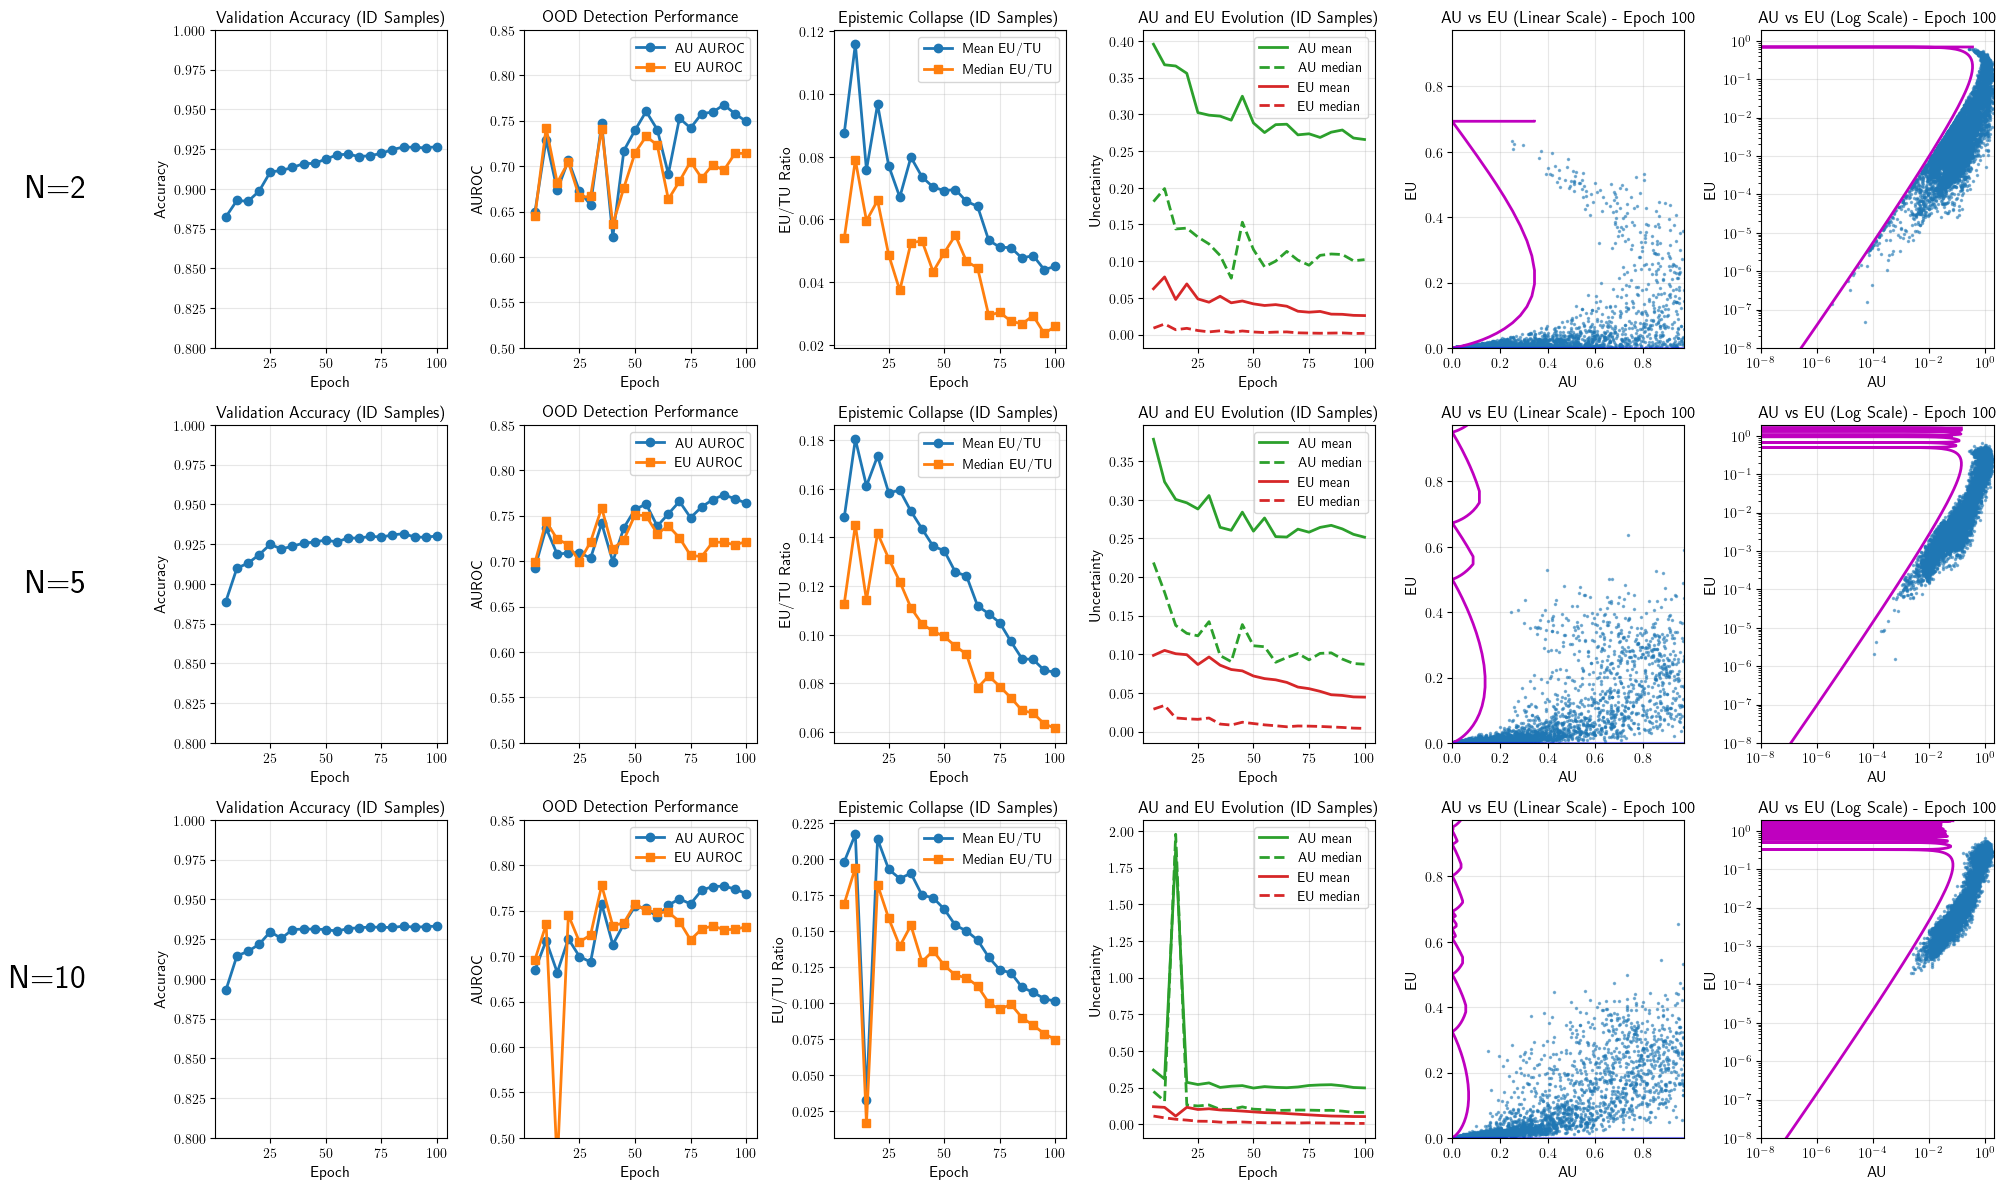

In [86]:
from pathlib import Path

fig, axs = plt.subplots(ncols=6, nrows=3, figsize=(20, 12))
for i,N in enumerate([2,5,10]):
    file_paths = entu.model_paths(r"./cifar/logs/2026-09-0*/*-C7-save10-ENetb{enet_b}{pre}-{i}/",
                                  pretrained=True, enet_b=6)
    file_paths = file_paths[:N]
    entu.ensemble_evolution_plot(file_paths, axs=axs[i], apply_temp=True);
    #plot N={N} to the left of leftmost plot
    axs[i,0].text(-0.55, 0.5, f"N={N}", fontsize=24, ha='right', va='center', 
                  rotation=0, fontweight='bold', transform=axs[i,0].transAxes)

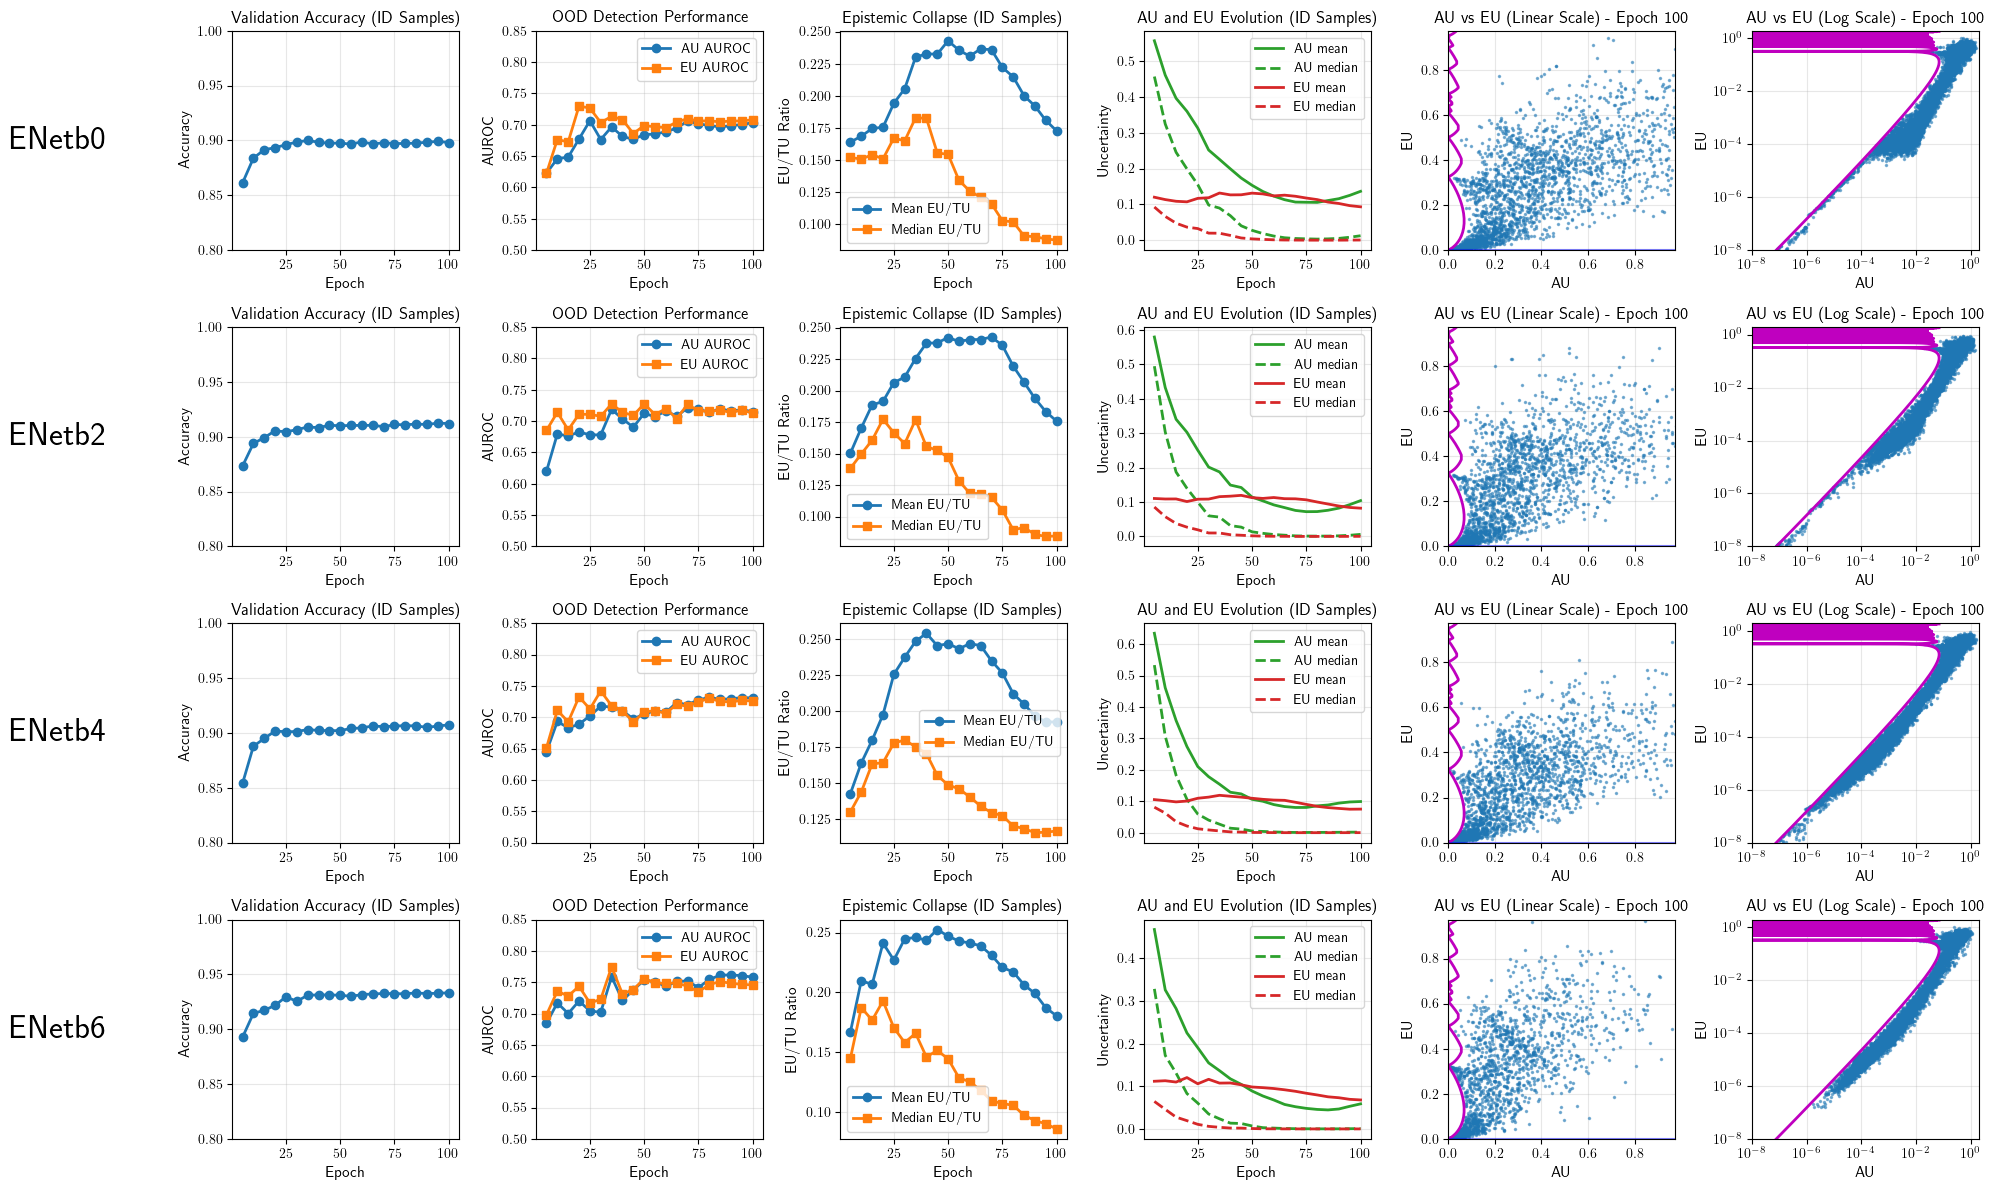

In [97]:
from pathlib import Path

fig, axs = plt.subplots(ncols=6, nrows=4, figsize=(20, 12))
for i,enet_b in enumerate([0,2,4,6]):
    file_paths = entu.model_paths(r"./cifar/logs/2026-09-0*/*-C7-save10-ENetb{enet_b}{pre}-{i}/",
                                  pretrained=True, enet_b=enet_b)
    entu.ensemble_evolution_plot(file_paths, axs=axs[i],apply_temp=False);
    #plot N={N} to the left of leftmost plot
    axs[i,0].text(-0.55, 0.5, f"ENetb{enet_b}", fontsize=24, ha='right', va='center', 
                  rotation=0, fontweight='bold', transform=axs[i,0].transAxes)

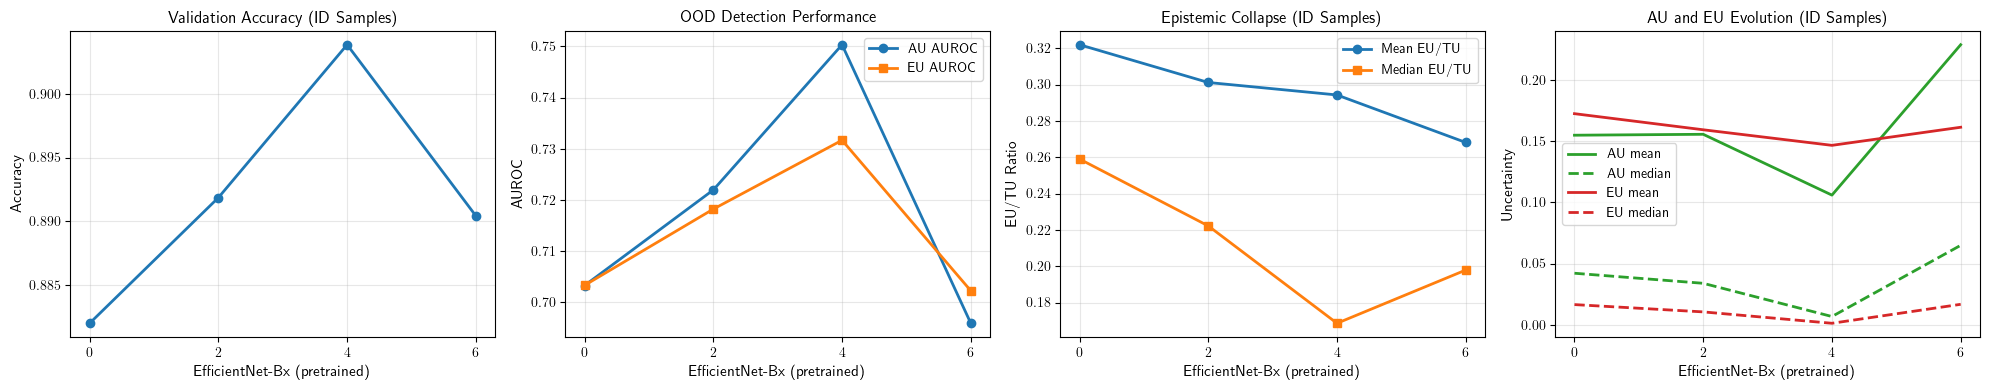

In [ ]:
import glob
file_paths = []
b_vals = [0,2,4,6]
for i in b_vals:
    file_paths.append(list(glob.glob(f"./cifar/logs/*/*-C7-save10-ENetb{i}-*/val_logits.csv")))
file_paths = [[f for f in f_i if '-pre-' not in f] for f_i in file_paths]
fig,_,_ = entu.progress_plot(file_paths,x=b_vals,xlabel="EfficientNet-Bx (scratch)")

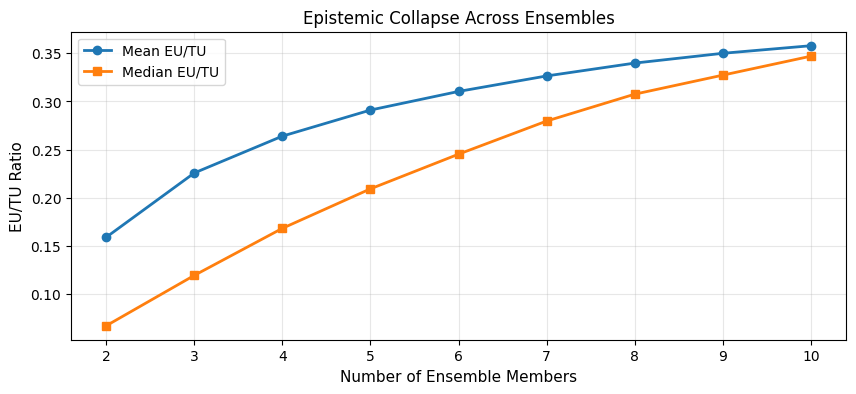

In [73]:

file_paths = entu.model_paths(r"./cifar/logs/2026-09-0*/*-C7-save10-ENetb{enet_b}{pre}-{i}/val_logits.csv",
                                pretrained=False, enet_b=0)
file_paths = [file_paths[:2+i] for i in range(len(file_paths)-1)]
fig,ax,metrics = entu.epistemic_collapse_plot(file_paths)
#change xlabel to "Number of Ensemble Members" and change from ["2","3","4","5","6","7","8","9","10"] but at 0-8 location
ax.set_xlabel("Number of Ensemble Members")
ax.set_xticks(range(len(file_paths)))
ax.set_xticklabels([str(i+2) for i in range(len(file_paths))]);

In [131]:
file_paths

['cifar/logs/2026-09-04/19-58-21-C7-save10-ENetb4-0',
 'cifar/logs/2026-09-04/20-28-50-C7-save10-ENetb4-1',
 'cifar/logs/2026-09-04/20-59-34-C7-save10-ENetb4-2',
 'cifar/logs/2026-09-04/21-30-16-C7-save10-ENetb4-3',
 'cifar/logs/2026-09-04/22-01-07-C7-save10-ENetb4-4',
 'cifar/logs/2026-09-04/22-31-50-C7-save10-ENetb4-5',
 'cifar/logs/2026-09-04/23-02-32-C7-save10-ENetb4-6',
 'cifar/logs/2026-09-04/23-33-03-C7-save10-ENetb4-7',
 'cifar/logs/2026-09-05/00-03-35-C7-save10-ENetb4-8',
 'cifar/logs/2026-09-05/00-34-10-C7-save10-ENetb4-9']

In [90]:
#resnet18 (11.18m), resnet50 (23.53m), efficientnet_b0 (4.02m), vit_b16 (85.81m)
#models = ["resnet18", "resnet50", "vit_b16"]
#model_names = ["ResNet-18", "ResNet-50", "ViT-B16"]
models = [f"efficientnet_b{i}" for i in [0,2,4,6]]
model_names = [f"ENetb{i}" for i in [0,2,4,6]]
for model, model_name in zip(models, model_names):
    for seed in range(10):
        print(f'python train.py seed={120+seed} data.id_classes="0123456" time_append="-C7-mnist-{model_name}-pre-{seed}" data.id_only_head=True training.save_logits_every_n_epochs=5 model.arch="{model}" model.pretrained=True training.epochs=100  dataset=mnist')
for model, model_name in zip(models, model_names):
    for seed in range(10):
        print(f'python train.py seed={120+seed} data.id_classes="0123456" time_append="-C7-mnist-{model_name}-scr-{seed}" data.id_only_head=True training.save_logits_every_n_epochs=20 model.arch="{model}" model.pretrained=False training.epochs=400 dataset=mnist')


python train.py seed=120 data.id_classes="0123456" time_append="-C7-mnist-ENetb0-pre-0" data.id_only_head=True training.save_logits_every_n_epochs=5 model.arch="efficientnet_b0" model.pretrained=True training.epochs=100  dataset=mnist
python train.py seed=121 data.id_classes="0123456" time_append="-C7-mnist-ENetb0-pre-1" data.id_only_head=True training.save_logits_every_n_epochs=5 model.arch="efficientnet_b0" model.pretrained=True training.epochs=100  dataset=mnist
python train.py seed=122 data.id_classes="0123456" time_append="-C7-mnist-ENetb0-pre-2" data.id_only_head=True training.save_logits_every_n_epochs=5 model.arch="efficientnet_b0" model.pretrained=True training.epochs=100  dataset=mnist
python train.py seed=123 data.id_classes="0123456" time_append="-C7-mnist-ENetb0-pre-3" data.id_only_head=True training.save_logits_every_n_epochs=5 model.arch="efficientnet_b0" model.pretrained=True training.epochs=100  dataset=mnist
python train.py seed=124 data.id_classes="0123456" time_appe



python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar-Res18-pre-test" data.id_only_head=True model.arch="resnet18" model.pretrained=True training.epochs=100 data.data_ratio=0.1

python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar-ENetb0-pre-test" data.id_only_head=True model.arch="efficientnet_b0" model.pretrained=True training.epochs=100 data.data_ratio=0.1

python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-ENetb0-scr-test" data.id_only_head=True model.arch="efficientnet_b0" model.pretrained=False training.epochs=400 data.data_ratio=0.1 training.val_per_epoch=1

In [119]:
# 0.1 ratio of training data
#resnet18 (11.18m), resnet50 (23.53m), efficientnet_b0 (4.02m), vit_b16 (85.81m)
#models = ["resnet18", "resnet50", "vit_b16"]
#model_names = ["ResNet-18", "ResNet-50", "ViT-B16"]
models = [f"efficientnet_b{i}" for i in [0,2,4,6]]
model_names = [f"ENetb{i}" for i in [0,2,4,6]]

# 1/10 dataset ensemble
# 40 models
for model, model_name in zip(models, model_names):
    for seed in range(10):
        print(f'python train.py seed=12{seed} data.id_classes="0123456" time_append="-C7-cifar01-{model_name}-pre-{seed}" model.arch="{model}" model.pretrained=True training.epochs=100 data.data_ratio=0.1')
# 40 models
for model, model_name in zip(models, model_names):
    for seed in range(10):
        print(f'python train.py seed=12{seed} data.id_classes="0123456" time_append="-C7-cifar01-{model_name}-scr-{seed}" model.arch="{model}" model.pretrained=False training.epochs=400 data.data_ratio=0.1')
# 40 models
for model, model_name in zip(models, model_names):
    for seed in range(10):
        print(f'python train.py seed=12{seed} data.id_classes="0123456" time_append="-C7-mnist01-{model_name}-pre-{seed}" model.arch="{model}" model.pretrained=True training.epochs=50 data.data_ratio=0.1 dataset=mnist')
# 40 models
for model, model_name in zip(models, model_names):
    for seed in range(10):
        print(f'python train.py seed=12{seed} data.id_classes="0123456" time_append="-C7-mnist01-{model_name}-scr-{seed}" model.arch="{model}" model.pretrained=False training.epochs=200 data.data_ratio=0.1 dataset=mnist')

# 1/10 dataset dropout
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-{model_name}-pre-dropout" model.arch="{model}" model.pretrained=True training.epochs=200 data.data_ratio=0.1 model.dropout_type=mc_dropout')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-{model_name}-scr-dropout" model.arch="{model}" model.pretrained=False training.epochs=800 data.data_ratio=0.1 model.dropout_type=mc_dropout')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-mnist01-{model_name}-pre-dropout" model.arch="{model}" model.pretrained=True training.epochs=100 data.data_ratio=0.1 dataset=mnist model.dropout_type=mc_dropout')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-mnist01-{model_name}-scr-dropout" model.arch="{model}" model.pretrained=False training.epochs=400 data.data_ratio=0.1 dataset=mnist model.dropout_type=mc_dropout')

# Full dataset dropout
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar-{model_name}-pre-dropout" model.arch="{model}" model.pretrained=True training.epochs=200 model.dropout_type=mc_dropout training.save_model=True')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar-{model_name}-scr-dropout" model.arch="{model}" model.pretrained=False training.epochs=800 model.dropout_type=mc_dropout training.save_model=True')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-mnist-{model_name}-pre-dropout" model.arch="{model}" model.pretrained=True training.epochs=100 dataset=mnist model.dropout_type=mc_dropout training.save_model=True')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-mnist-{model_name}-scr-dropout" model.arch="{model}" model.pretrained=False training.epochs=400 dataset=mnist model.dropout_type=mc_dropout training.save_model=True')

python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-ENetb0-pre-0" model.arch="efficientnet_b0" model.pretrained=True training.epochs=100 data.data_ratio=0.1
python train.py seed=121 data.id_classes="0123456" time_append="-C7-cifar01-ENetb0-pre-1" model.arch="efficientnet_b0" model.pretrained=True training.epochs=100 data.data_ratio=0.1
python train.py seed=122 data.id_classes="0123456" time_append="-C7-cifar01-ENetb0-pre-2" model.arch="efficientnet_b0" model.pretrained=True training.epochs=100 data.data_ratio=0.1
python train.py seed=123 data.id_classes="0123456" time_append="-C7-cifar01-ENetb0-pre-3" model.arch="efficientnet_b0" model.pretrained=True training.epochs=100 data.data_ratio=0.1
python train.py seed=124 data.id_classes="0123456" time_append="-C7-cifar01-ENetb0-pre-4" model.arch="efficientnet_b0" model.pretrained=True training.epochs=100 data.data_ratio=0.1
python train.py seed=125 data.id_classes="0123456" time_append="-C7-cifar01-ENetb0-pre-5" model

python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar-ENetb0-src-dropout-r02" model.arch="efficientnet_b0" model.pretrained=False training.epochs=400 data.data_ratio=1.0 model.dropout_type=mc_dropout model.mc_dropout_p=0.2


training.save_logits_every_n_epochs=10

python train.py seed=120 data.id_classes="0123456789" time_append="-TEST" model.arch="efficientnet_b0"

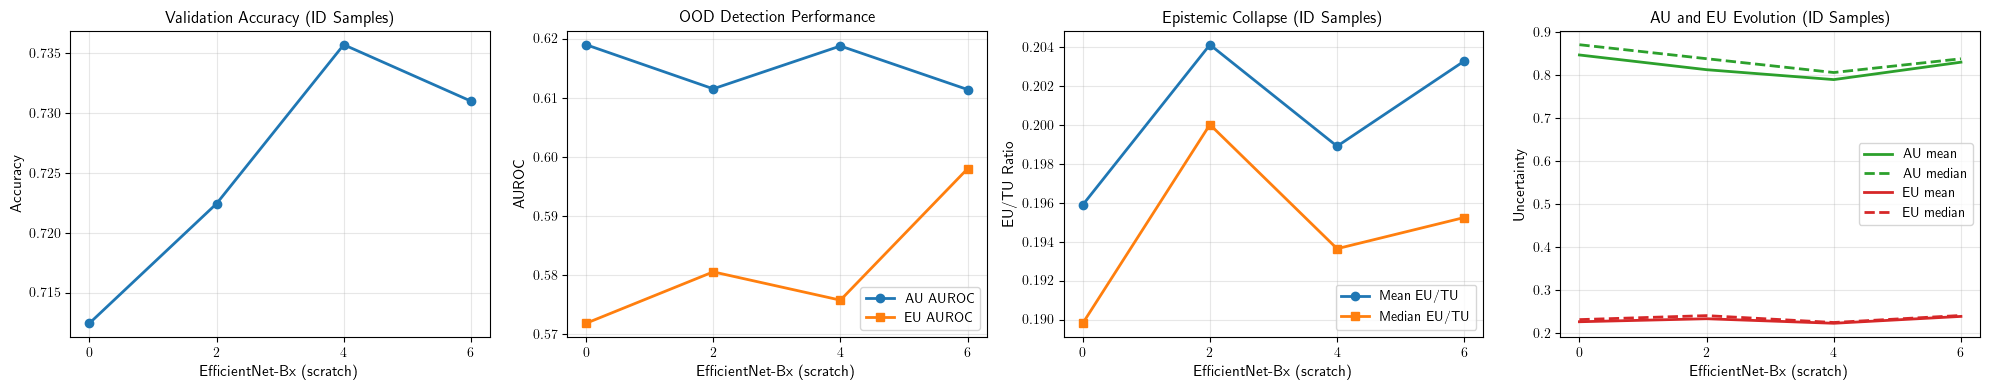

In [126]:
import glob
file_paths = []
b_vals = [0,2,4,6]
for i in b_vals:
    file_paths.append(list(glob.glob(f"./cifar/logs/*/*-C7-cifar01-ENetb{i}-scr-*/val_logits.csv")))
fig,_,_ = entu.progress_plot(file_paths,x=b_vals,xlabel="EfficientNet-Bx (scratch)", apply_temp=True)

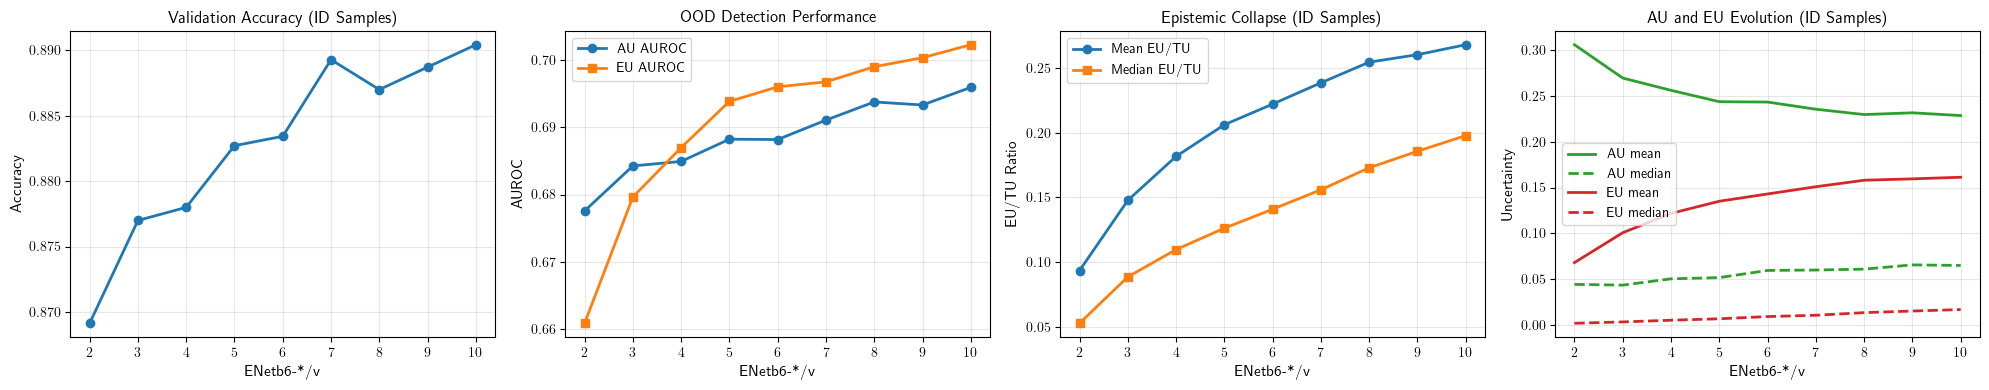

In [ ]:
import glob
file_paths = []
N_vals = list(range(2,11))
apply_temp = False
s = f"./cifar/logs/*/*-C7-cifar01-ENetb6-*/val_logits.csv"
file_paths0 = list(glob.glob(s))
file_paths0 = [f for f in file_paths0 if '-pre-' not in f]
for i in N_vals:
    file_paths.append(file_paths0[:i])
#idx of ENet and then next 10 chars
i_b = s.index("ENetb")
xlabel = s[i_b:i_b+10]
if apply_temp:
    xlabel += " (temp-scaled)"
fig,_,_ = entu.progress_plot(file_paths,x=N_vals,xlabel=xlabel, apply_temp=apply_temp)

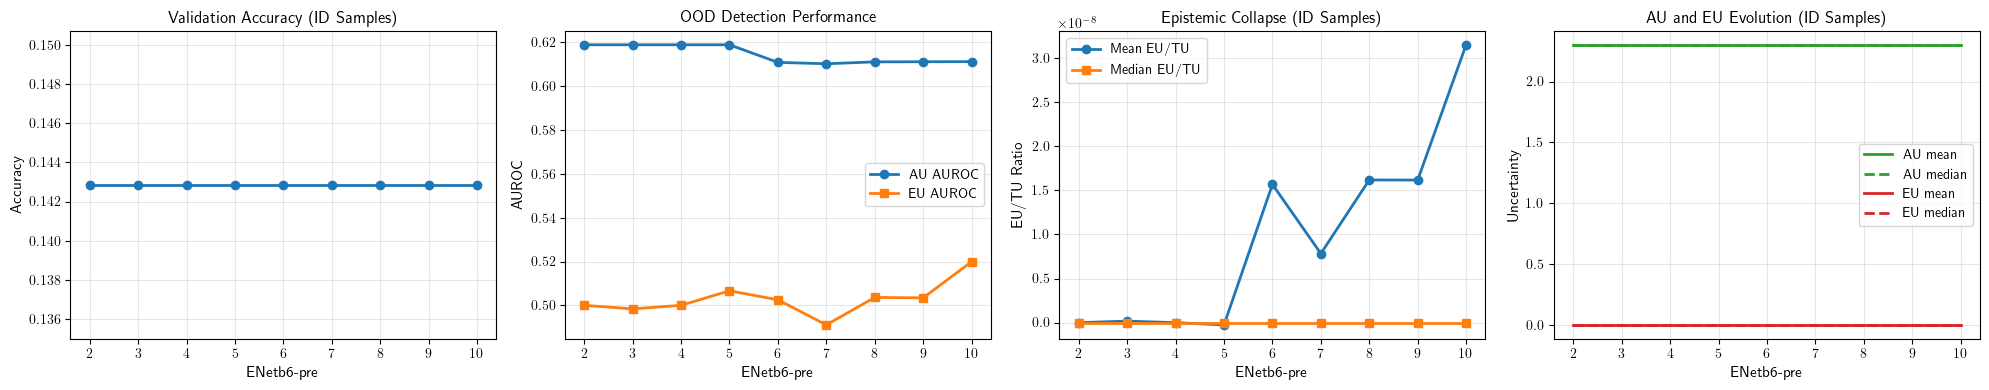

In [154]:
import glob
file_paths = []
N_vals = list(range(2,11))
apply_temp = False
s = f"./cifar/logs/*/*-C7-cifar01-ENetb6-pre-dropout/val_logits/*.csv"
file_paths0 = list(glob.glob(s))
assert len(file_paths0)>0
for i in N_vals:
    file_paths.append(file_paths0[:i])
#idx of ENet and then next 10 chars
i_b = s.index("ENetb")
xlabel = s[i_b:i_b+10]
if apply_temp:
    xlabel += " (temp-scaled)"
fig,_,_ = entu.progress_plot(file_paths,x=N_vals,xlabel=xlabel, apply_temp=apply_temp)

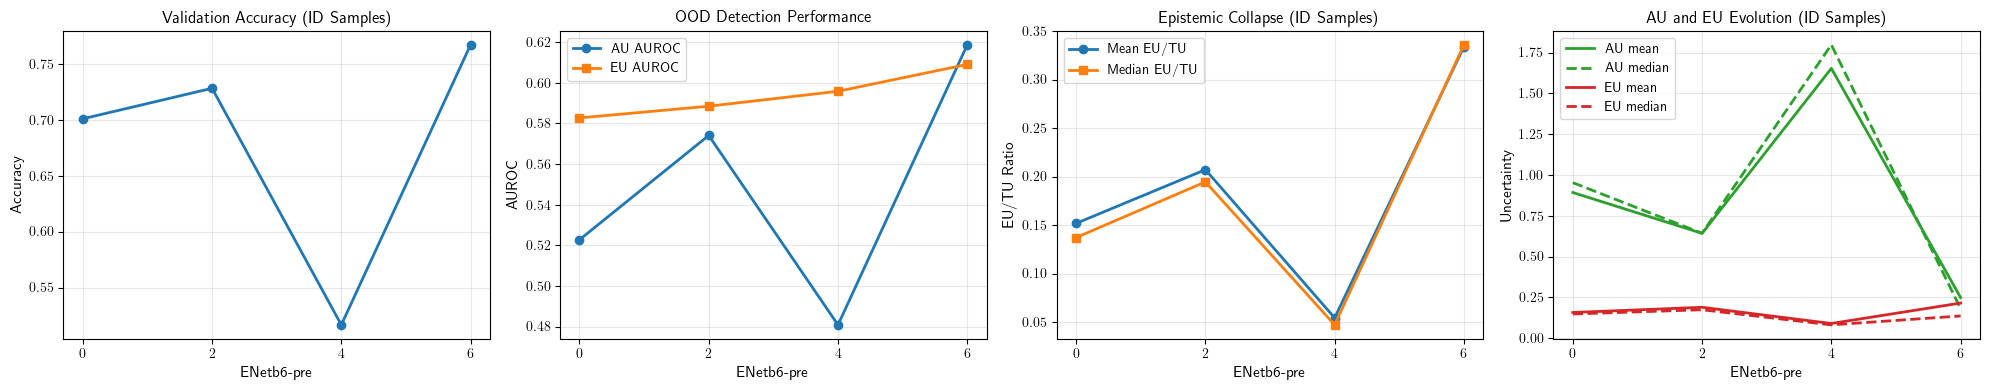

In [161]:
import glob
file_paths = []
b_vals = [0,2,4,6]
apply_temp = False
file_paths = []
for b in b_vals:
    s = f"./cifar/logs/*/*-C7-cifar01-ENetb{b}-pre-dropout/val_logits/*.csv"
    file_paths.append(list(glob.glob(s)))
assert all(len(fp)>0 for fp in file_paths)
i_b = s.index("ENetb")
xlabel = s[i_b:i_b+10]
if apply_temp:
    xlabel += " (temp-scaled)"
fig,_,_ = entu.progress_plot(file_paths,x=b_vals,xlabel=xlabel, apply_temp=apply_temp)

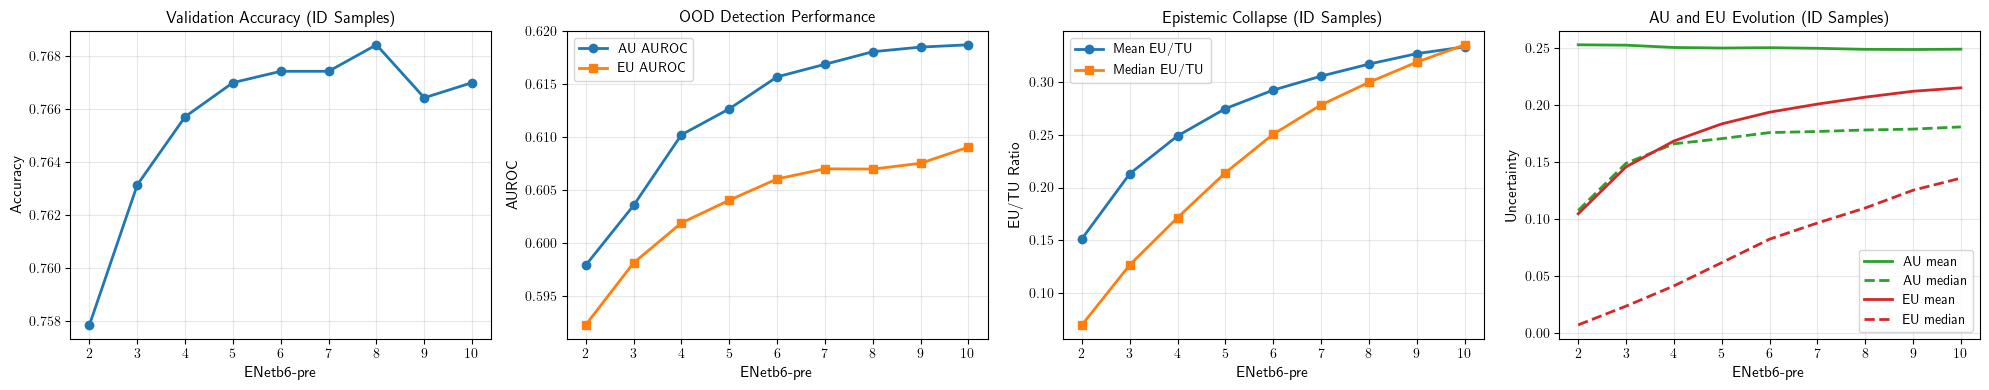

In [162]:
import glob
file_paths = []
N_vals = list(range(2,11))
apply_temp = False
s = f"./cifar/logs/*/*-C7-cifar01-ENetb6-pre-dropout/val_logits/*.csv"
file_paths0 = list(glob.glob(s))
file_paths = []
for N in N_vals:
    file_paths.append(file_paths0[:N])
assert all(len(fp)>0 for fp in file_paths)
i_b = s.index("ENetb")
xlabel = s[i_b:i_b+10]
if apply_temp:
    xlabel += " (temp-scaled)"
fig,_,_ = entu.progress_plot(file_paths,x=N_vals,xlabel=xlabel, apply_temp=apply_temp)

In [160]:
models = [f"efficientnet_b{i}" for i in [0,2,4,6]]
model_names = [f"ENetb{i}" for i in [0,2,4,6]]

# 1/10 dataset dropout
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-{model_name}-pre-dropout" model.arch="{model}" model.pretrained=True training.epochs=400 data.data_ratio=0.1 model.dropout_type=mc_dropout')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-{model_name}-scr-dropout" model.arch="{model}" model.pretrained=False training.epochs=800 data.data_ratio=0.1 model.dropout_type=mc_dropout')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-mnist01-{model_name}-pre-dropout" model.arch="{model}" model.pretrained=True training.epochs=200 data.data_ratio=0.1 dataset=mnist model.dropout_type=mc_dropout')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-mnist01-{model_name}-scr-dropout" model.arch="{model}" model.pretrained=False training.epochs=400 data.data_ratio=0.1 dataset=mnist model.dropout_type=mc_dropout')
"""
# Full dataset dropout
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar-{model_name}-pre-dropout" model.arch="{model}" model.pretrained=True training.epochs=400 model.dropout_type=mc_dropout training.save_model=True')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar-{model_name}-scr-dropout" model.arch="{model}" model.pretrained=False training.epochs=800 model.dropout_type=mc_dropout training.save_model=True')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-mnist-{model_name}-pre-dropout" model.arch="{model}" model.pretrained=True training.epochs=200 dataset=mnist model.dropout_type=mc_dropout training.save_model=True')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-mnist-{model_name}-scr-dropout" model.arch="{model}" model.pretrained=False training.epochs=400 dataset=mnist model.dropout_type=mc_dropout training.save_model=True')""";

python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-ENetb0-pre-dropout" model.arch="efficientnet_b0" model.pretrained=True training.epochs=400 data.data_ratio=0.1 model.dropout_type=mc_dropout
python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-ENetb2-pre-dropout" model.arch="efficientnet_b2" model.pretrained=True training.epochs=400 data.data_ratio=0.1 model.dropout_type=mc_dropout
python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-ENetb4-pre-dropout" model.arch="efficientnet_b4" model.pretrained=True training.epochs=400 data.data_ratio=0.1 model.dropout_type=mc_dropout
python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-ENetb6-pre-dropout" model.arch="efficientnet_b6" model.pretrained=True training.epochs=400 data.data_ratio=0.1 model.dropout_type=mc_dropout
python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-ENetb0-scr-dropout" model.arch="efficientnet_b0" model.p

In [164]:
models = [f"efficientnet_b{i}" for i in [1,3,5,7]]
model_names = [f"ENetb{i}" for i in [1,3,5,7]]

# 1/10 dataset dropout
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-{model_name}-pre-dropout" model.arch="{model}" model.pretrained=True training.epochs=400 data.data_ratio=0.1 model.dropout_type=mc_dropout')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-{model_name}-scr-dropout" model.arch="{model}" model.pretrained=False training.epochs=800 data.data_ratio=0.1 model.dropout_type=mc_dropout')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-mnist01-{model_name}-pre-dropout" model.arch="{model}" model.pretrained=True training.epochs=200 data.data_ratio=0.1 dataset=mnist model.dropout_type=mc_dropout')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-mnist01-{model_name}-scr-dropout" model.arch="{model}" model.pretrained=False training.epochs=400 data.data_ratio=0.1 dataset=mnist model.dropout_type=mc_dropout')
"""
# Full dataset dropout
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar-{model_name}-pre-dropout" model.arch="{model}" model.pretrained=True training.epochs=400 model.dropout_type=mc_dropout training.save_model=True')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar-{model_name}-scr-dropout" model.arch="{model}" model.pretrained=False training.epochs=800 model.dropout_type=mc_dropout training.save_model=True')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-mnist-{model_name}-pre-dropout" model.arch="{model}" model.pretrained=True training.epochs=200 dataset=mnist model.dropout_type=mc_dropout training.save_model=True')
# 4 models
for model, model_name in zip(models, model_names):
    print(f'python train.py seed=120 data.id_classes="0123456" time_append="-C7-mnist-{model_name}-scr-dropout" model.arch="{model}" model.pretrained=False training.epochs=400 dataset=mnist model.dropout_type=mc_dropout training.save_model=True')""";

python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-ENetb1-pre-dropout" model.arch="efficientnet_b1" model.pretrained=True training.epochs=400 data.data_ratio=0.1 model.dropout_type=mc_dropout
python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-ENetb3-pre-dropout" model.arch="efficientnet_b3" model.pretrained=True training.epochs=400 data.data_ratio=0.1 model.dropout_type=mc_dropout
python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-ENetb5-pre-dropout" model.arch="efficientnet_b5" model.pretrained=True training.epochs=400 data.data_ratio=0.1 model.dropout_type=mc_dropout
python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-ENetb7-pre-dropout" model.arch="efficientnet_b7" model.pretrained=True training.epochs=400 data.data_ratio=0.1 model.dropout_type=mc_dropout
python train.py seed=120 data.id_classes="0123456" time_append="-C7-cifar01-ENetb1-scr-dropout" model.arch="efficientnet_b1" model.p

In [184]:
models = [f"efficientnet_b{i}" for i in [0,2,4,6]]
model_names = [f"ENetb{i}" for i in [0,2,4,6]]

def get_training_cmd(model="ens",
                     enet_b=0,
                     data="cifar",
                     pretrained=False,
                     num_ens_seeds=10,
                     epochs=None,
                     save_model=None,
                     name="BASE",
                     no_ood_classes=False,
                     save_logits_every_n_epochs=None,
                     data_ratio=None):
    if epochs is None:
        epochs = 200
        if model=="dropout":
            epochs *= 2
        if data=="cifar":
            epochs *= 2
        if data_ratio is not None:
            epochs *= 2
        mult = [1,1,1,1,1.5,1.5,2,2][enet_b]
        epochs *= mult
        epochs = int(epochs)
    if save_model is None:
        save_model = model=="dropout" # only save dropout
    if model=="ens":
        s = f'python train.py seed=12[SEED] data.id_classes="0123456" time_append="-{name}-{data}-Enetb{enet_b}-scr-{model}[SEED]" model.arch="efficientnet_b{enet_b}" training.epochs={epochs} model.dropout_type=mc_dropout'
    elif model=="dropout":
        s = f'python train.py seed=120 data.id_classes="0123456" time_append="-{name}-{data}-Enetb{enet_b}-scr-{model}" model.arch="efficientnet_b{enet_b}" training.epochs={epochs} model.dropout_type=mc_dropout'
    else:
        raise ValueError(f"Unknown model type: {model}")

    if data=="mnist":
        s += " dataset=mnist"
    if pretrained:
        s += " model.pretrained=True"
    if save_model:
        s += " training.save_model=True"
    if no_ood_classes:
        s += ' data.id_classes="0123456789"'
    if save_logits_every_n_epochs:
        s += f" training.save_logits_every_n_epochs={save_logits_every_n_epochs}"
    if data_ratio is not None:
        s += f" data.data_ratio={data_ratio}"
    if model=="dropout":
        return [s]
    elif model=="ens":
        return [s.replace("[SEED]", str(seed)) for seed in range(num_ens_seeds)]

cmds = []
############### Base ###############
for data in ["cifar", "mnist"]:
    for model in ["ens", "dropout"]:
        for enet_b in [0,2,4,6]:
            cmds.extend(get_training_cmd(model=model, enet_b=enet_b, data=data, name="BASE"))
cmds.append("")
############### C=10 ###############
for data in ["cifar", "mnist"]:
    for model in ["ens", "dropout"]:
        for enet_b in [0]:
            cmds.extend(get_training_cmd(model=model, enet_b=enet_b, data=data, no_ood_classes=True, name="C10"))
cmds.append("")
############### epoch ###############
for data in ["cifar", "mnist"]:
    for model in ["ens", "dropout"]:
        for enet_b in [6]:
            cmds.extend(get_training_cmd(model=model, enet_b=enet_b, data=data, 
                                         save_logits_every_n_epochs=20, name="EPOCH"))
cmds.append("")

############### 10% ###############
for data in ["cifar", "mnist"]:
    for model in ["ens", "dropout"]:
        for enet_b in [0,2,4,6]:
            cmds.extend(get_training_cmd(model=model, enet_b=enet_b, data=data, data_ratio=0.1, name="10PCT"))
cmds.append("")

############### ens50 ###############
for data in ["cifar", "mnist"]:
    for model in ["ens"]:
        for enet_b in [0]:
            cmds.extend(get_training_cmd(model=model, enet_b=enet_b, data=data, num_ens_seeds=50, name="ENS50"))
cmds.append("")
print(len(cmds))

#print lines after empty lines
for i, line in enumerate(cmds):
    if line=="":
        print(cmds[(i-1) % len(cmds)])

325
python train.py seed=120 data.id_classes="0123456" time_append="-BASE-mnist-Enetb6-scr-dropout" model.arch="efficientnet_b6" training.epochs=800 model.dropout_type=mc_dropout dataset=mnist training.save_model=True
python train.py seed=120 data.id_classes="0123456" time_append="-C10-mnist-Enetb0-scr-dropout" model.arch="efficientnet_b0" training.epochs=400 model.dropout_type=mc_dropout dataset=mnist training.save_model=True data.id_classes="0123456789"
python train.py seed=120 data.id_classes="0123456" time_append="-EPOCH-mnist-Enetb6-scr-dropout" model.arch="efficientnet_b6" training.epochs=800 model.dropout_type=mc_dropout dataset=mnist training.save_model=True training.save_logits_every_n_epochs=20
python train.py seed=120 data.id_classes="0123456" time_append="-10PCT-mnist-Enetb6-scr-dropout" model.arch="efficientnet_b6" training.epochs=1600 model.dropout_type=mc_dropout dataset=mnist training.save_model=True data.data_ratio=0.1
python train.py seed=1249 data.id_classes="0123456

In [187]:
for line in cmds:
    print(line)

python train.py seed=120 data.id_classes="0123456" time_append="-BASE-cifar-Enetb0-scr-ens0" model.arch="efficientnet_b0" training.epochs=400 model.dropout_type=mc_dropout
python train.py seed=121 data.id_classes="0123456" time_append="-BASE-cifar-Enetb0-scr-ens1" model.arch="efficientnet_b0" training.epochs=400 model.dropout_type=mc_dropout
python train.py seed=122 data.id_classes="0123456" time_append="-BASE-cifar-Enetb0-scr-ens2" model.arch="efficientnet_b0" training.epochs=400 model.dropout_type=mc_dropout
python train.py seed=123 data.id_classes="0123456" time_append="-BASE-cifar-Enetb0-scr-ens3" model.arch="efficientnet_b0" training.epochs=400 model.dropout_type=mc_dropout
python train.py seed=124 data.id_classes="0123456" time_append="-BASE-cifar-Enetb0-scr-ens4" model.arch="efficientnet_b0" training.epochs=400 model.dropout_type=mc_dropout
python train.py seed=125 data.id_classes="0123456" time_append="-BASE-cifar-Enetb0-scr-ens5" model.arch="efficientnet_b0" training.epochs=40

In [206]:
models = [f"efficientnet_b{i}" for i in [0,2,4,6]]
model_names = [f"ENetb{i}" for i in [0,2,4,6]]

def get_training_cmd(model="ens",
                     enet_b=0,
                     data="cifar",
                     pretrained=False,
                     num_ens_seeds=10,
                     epochs=None,
                     save_model=None,
                     name="BASE",
                     no_ood_classes=False,
                     save_logits_every_n_epochs=None,
                     data_ratio=None):
    if epochs is None:
        epochs = 200
        if model=="dropout":
            epochs *= 2
        if data=="cifar":
            epochs *= 2
        if data_ratio is not None:
            epochs *= 2
        mult = [1,1,1,1,1.5,1.5,2,2][enet_b]
        epochs *= mult
        epochs = int(epochs)
    if save_model is None:
        save_model = model=="dropout" # only save dropout
    if model=="ens":
        s = f'python train.py seed=12[SEED] data.id_classes="0123456" time_append="-{name}-{data}-Enetb{enet_b}-scr-{model}[SEED]" model.arch="efficientnet_b{enet_b}" training.epochs={epochs} model.dropout_type=mc_dropout'
    elif model=="dropout":
        s = f'python train.py seed=120 data.id_classes="0123456" time_append="-{name}-{data}-Enetb{enet_b}-scr-{model}" model.arch="efficientnet_b{enet_b}" training.epochs={epochs} model.dropout_type=mc_dropout'
    else:
        raise ValueError(f"Unknown model type: {model}")

    if data=="mnist":
        s += " dataset=mnist"
    if pretrained:
        s += " model.pretrained=True"
    if save_model:
        s += " training.save_model=True"
    if no_ood_classes:
        s += ' data.id_classes="0123456789"'
    if save_logits_every_n_epochs:
        s += f" training.save_logits_every_n_epochs={save_logits_every_n_epochs}"
    if data_ratio is not None:
        s += f" data.data_ratio={data_ratio}"
    if model=="dropout":
        return [s]
    elif model=="ens":
        return [s.replace("[SEED]", str(seed)) for seed in range(num_ens_seeds)]

cmds = []
############### Base ###############
for data in ["cifar", "mnist"]:
    for model in ["ens", "dropout"]:
        for enet_b in [0,2,4,6]:
            cmds.extend(get_training_cmd(model=model, enet_b=enet_b, data=data, name="BASE"))
cmds.append("")
############### C=10 ###############
for data in ["cifar", "mnist"]:
    for model in ["ens", "dropout"]:
        for enet_b in [0]:
            cmds.extend(get_training_cmd(model=model, enet_b=enet_b, data=data, no_ood_classes=True, name="C10"))
cmds.append("")
############### epoch ###############
for data in ["cifar", "mnist"]:
    for model in ["ens", "dropout"]:
        for enet_b in [6]:
            cmds.extend(get_training_cmd(model=model, enet_b=enet_b, data=data, 
                                         save_logits_every_n_epochs=20, name="EPOCH"))
cmds.append("")

############### 10% ###############
for data in ["cifar", "mnist"]:
    for model in ["ens", "dropout"]:
        for enet_b in [0,2,4,6]:
            cmds.extend(get_training_cmd(model=model, enet_b=enet_b, data=data, data_ratio=0.1, name="10PCT"))
cmds.append("")

############### ens50 ###############
for data in ["cifar", "mnist"]:
    for model in ["ens"]:
        for enet_b in [0]:
            cmds.extend(get_training_cmd(model=model, enet_b=enet_b, data=data, num_ens_seeds=50, name="ENS50"))
cmds.append("")
print(len(cmds))

ite_per_second = {"b0": 109600/(31.12/60*3600), 
                  "b2": 109600/(42.06/60*3600), 
                  "b4": 164400/(1.461*3600), 
                  "b6": 219200/(2.95*3600)}
ite_per_dataset = {"cifar": 50000//128,
                   "mnist": 60000//128}

current_training_cmd_idx = 98

325


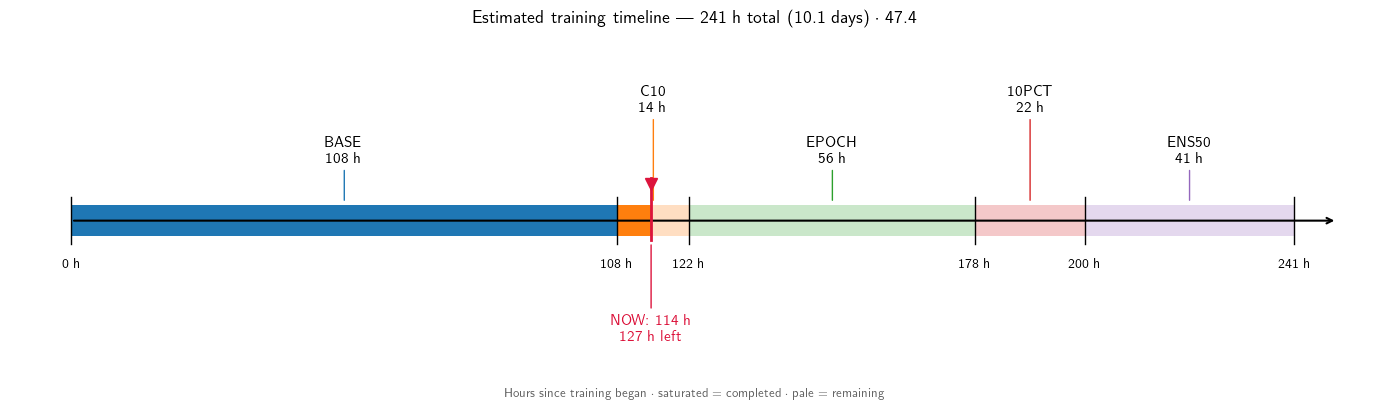

In [209]:
"""Import plot_training_timeline and call it after generating your cmds list."""

import shlex
import numpy as np
import matplotlib.pyplot as plt


def plot_training_timeline(
    cmds, ite_per_second, ite_per_dataset, current_training_cmd_idx,
    current_epoch=0, index_includes_separators=True,
):
    """Estimate sequential training time; indices are zero-based.

    current_epoch is completed epochs in the current command (can be fractional).
    Set index_includes_separators=False if the index counts only nonempty commands.
    An index equal to the relevant list length means all training is complete.
    Iteration counts are used as supplied, scaled by data.data_ratio only.
    Times exclude overhead and pauses and are estimates, not measured wall time.
    """
    sequence = list(cmds)
    if not index_includes_separators:
        sequence = [cmd for cmd in sequence if cmd.strip()]
    idx = current_training_cmd_idx
    if not isinstance(idx, (int, np.integer)) or not 0 <= idx <= len(sequence):
        raise ValueError("Current index must be an integer between 0 and list length.")
    if not np.isfinite(current_epoch) or current_epoch < 0:
        raise ValueError("current_epoch must be finite and nonnegative.")

    runs = []
    for i, cmd in enumerate(sequence):
        if not cmd.strip():
            continue
        # shlex removes shell quotes; later duplicate overrides take precedence.
        args = dict(token.split("=", 1) for token in shlex.split(cmd) if "=" in token)
        arch = args["model.arch"].removeprefix("efficientnet_")
        dataset = args.get("dataset", "cifar")
        sweep = args["time_append"].lstrip("-").split("-", 1)[0]
        epochs = int(args["training.epochs"])
        ratio = float(args.get("data.data_ratio", 1))
        is_C10 = "-C10-" in cmd
        speed = ite_per_second[arch]
        iterations = ite_per_dataset[dataset]
        if epochs <= 0 or not 0 < ratio <= 1 or speed <= 0 or iterations <= 0:
            raise ValueError(f"Invalid duration inputs at command {i}.")
        mod = 1.0 if is_C10 else 0.7
        hours = epochs * iterations * ratio / speed / 3600 * mod
        runs.append(dict(index=i, sweep=sweep, epochs=epochs, hours=hours))
    if not runs:
        raise ValueError("No training commands found.")

    active = next((r for r in runs if r["index"] == idx), None)
    if current_epoch and active is None:
        raise ValueError("Nonzero current_epoch requires an index pointing to a command.")
    if active is not None and current_epoch > active["epochs"]:
        raise ValueError("current_epoch exceeds this command's training.epochs.")
    elapsed = sum(r["hours"] for r in runs if r["index"] < idx)
    if active is not None:
        elapsed += active["hours"] * current_epoch / active["epochs"]

    # Keep consecutive sweep blocks in execution order.
    blocks = []
    for run in runs:
        if not blocks or blocks[-1]["name"] != run["sweep"]:
            blocks.append(dict(name=run["sweep"], hours=0.0, count=0, hour_list=[]))
        blocks[-1]["hours"] += run["hours"]
        blocks[-1]["count"] += 1
        blocks[-1]["hour_list"].append(run["hours"])
    boundaries = np.r_[0, np.cumsum([b["hours"] for b in blocks])]
    total = boundaries[-1]
    remaining = max(0.0, total - elapsed)

    fig, ax = plt.subplots(figsize=(14, 4.2))
    colors = plt.get_cmap("tab10").colors
    for j, block in enumerate(blocks):
        start, end = boundaries[j:j + 2]
        color = colors[j % len(colors)]
        # Pale = future training; saturated = completed training.
        ax.barh(0, end - start, left=start, height=0.16,
                color=color, alpha=0.25, zorder=2)
        done = max(0.0, min(elapsed, end) - start)
        ax.barh(0, done, left=start, height=0.16, color=color, zorder=3)
        # Stagger adjacent labels to accommodate shorter sweep sections.
        ax.annotate(f"{block['name']}\n{block['hours']:.0f} h",
                    xy=((start + end) / 2, 0.09),
                    xytext=((start + end) / 2, 0.36 + 0.26 * (j % 2)),
                    ha="center", va="center", fontsize=11,
                    arrowprops=dict(arrowstyle="-", color=color, lw=1))

    ax.annotate("", xy=(total * 1.035, 0), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.5), zorder=4)
    for time in boundaries:
        ax.plot([time, time], [-0.12, 0.12], color="black", lw=1, zorder=5)
        ax.text(time, -0.19, f"{time:.0f} h", ha="center", va="top", fontsize=10)

    ax.plot([elapsed, elapsed], [-0.10, 0.22], color="crimson", lw=2, zorder=6)
    ax.plot(elapsed, 0.19, marker="v", color="crimson", markersize=9, zorder=7)
    ax.annotate(f"NOW: {elapsed:.0f} h\n{remaining:.0f} h left",
                xy=(elapsed, -0.11), xytext=(elapsed, -0.55),
                ha="center", va="center", color="crimson", fontsize=11,
                fontweight="bold", arrowprops=dict(arrowstyle="-", color="crimson"))
    ax.set_title(f"Estimated training timeline — {total:.0f} h total "
                 f"({total / 24:.1f} days) · {elapsed / total:.1%} complete",
                 fontsize=13, pad=16)
    ax.text(0.5, 0, "Hours since training began · saturated = completed · pale = remaining",
            transform=ax.transAxes, ha="center", fontsize=9, color="0.4")
    ax.set_xlim(-0.05 * total, 1.07 * total)
    ax.set_ylim(-0.9, 0.9)
    ax.axis("off")
    fig.tight_layout()
    return fig, ax, dict(elapsed_hours=elapsed, remaining_hours=remaining,
                         total_hours=total, sweeps=blocks)

fig, ax, timing = plot_training_timeline(
    cmds,
    ite_per_second,
    ite_per_dataset,
    current_training_cmd_idx=98,
    current_epoch=0,                  # Completed epochs in current command
    index_includes_separators=True,  # Index into original cmds, including ""
)
plt.show()